In [1]:
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN
from vmdpy import VMD
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dense, Dropout
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --------------------------- 1. 数据加载与预处理 ---------------------------
def load_data(filepath):
    df = pd.read_excel(filepath, sheet_name='datas')
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', dayfirst=True)
    df.set_index('date', inplace=True)
    full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    return df.reindex(full_date_range).ffill()

df = load_data('C:/Users/18320/Desktop/carbon-Yunnan.xlsx')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

# --------------------------- 2. 固定参数设置 ---------------------------
# CEEMDAN参数
CEEMDAN_EPSILON = 0.01
CEEMDAN_ETA = 0.05

# VMD参数（用于高频模态二次分解）
VMD_ALPHA = 1200
VMD_K = 3

# BiLSTM参数
LSTM_UNITS = 128
GRU_UNITS = 128
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
N_STEPS = 24
EPOCHS = 100
BATCH_SIZE = 32

# 聚类参数
N_CLUSTERS = 3

# --------------------------- 3. 分解函数 ---------------------------
def ceemdan_decomposition(signal, epsilon, eta):
    """CEEMDAN分解"""
    ceemdan = CEEMDAN(epsilon=epsilon, 
                     eta=eta,
                     noise_strength=0.05,
                     ensemble_size=50)
    imfs = ceemdan.ceemdan(signal.flatten())
    return np.array(imfs).T

def vmd_decomposition(signal, alpha, K):
    """VMD分解"""
    imfs, _, _ = VMD(signal.flatten(), alpha=alpha, K=K, tau=0, DC=0, init=1, tol=1e-6)
    return imfs

# --------------------------- 4. IMF聚类函数 ---------------------------
def cluster_imfs(imfs, n_clusters=3):
    """基于频率特性对IMF进行聚类"""
    n_imfs = imfs.shape[1]
    features = []
    
    for i in range(n_imfs):
        imf = imfs[:, i]
        # 计算过零率（高频特征）
        zero_crossings = np.sum(np.diff(np.sign(imf)) != 0) / len(imf)
        
        # 计算能量（幅值特征）
        energy = np.sum(imf**2)
        
        # 计算自相关第一个零点（周期性特征）
        autocorr = np.correlate(imf, imf, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        first_zero = np.argmax(autocorr < 0.1 * autocorr[0]) if np.any(autocorr < 0.1 * autocorr[0]) else len(autocorr)-1
        
        features.append([zero_crossings, energy, first_zero])
    
    features = np.array(features)
    
    # 标准化特征
    feature_scaler = MinMaxScaler()
    normalized_features = feature_scaler.fit_transform(features)
    
    # K-means聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(normalized_features)
    
    return labels, features, kmeans

# --------------------------- 5. IMF合并函数（新增）---------------------------
def merge_imfs_by_cluster(imfs, labels):
    """将同一聚类内的IMF合并为一个分量"""
    n_clusters = np.max(labels) + 1
    merged_components = []
    
    for cluster_id in range(n_clusters):
        # 找到属于当前聚类的所有IMF索引
        cluster_indices = np.where(labels == cluster_id)[0]
        
        if len(cluster_indices) > 0:
            # 将同一聚类内的IMF相加合并
            merged_component = np.sum(imfs[:, cluster_indices], axis=1)
            merged_components.append(merged_component)
    
    return np.array(merged_components).T

# --------------------------- 6. 高频模态VMD二次分解 ---------------------------
def refine_high_frequency_components(merged_components, labels, original_imfs, vmd_alpha, vmd_k):
    """对高频聚类分量进行VMD二次分解"""
    # 找到高频聚类（过零率最高的聚类）
    cluster_features = []
    for i in range(np.max(labels)+1):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) > 0:
            # 使用原始IMF计算过零率
            avg_zero_crossing = np.mean([np.sum(np.diff(np.sign(original_imfs[:, idx])) != 0) / len(original_imfs) for idx in cluster_indices])
            cluster_features.append(avg_zero_crossing)
        else:
            cluster_features.append(0)
    
    high_freq_cluster = np.argmax(cluster_features)
    
    # 对高频聚类分量进行VMD二次分解
    refined_components = []
    for i in range(merged_components.shape[1]):
        if i == high_freq_cluster:
            # 对高频分量进行VMD分解
            vmd_imfs = vmd_decomposition(merged_components[:, i], vmd_alpha, vmd_k)
            refined_components.extend(vmd_imfs)
        else:
            # 非高频分量保持不变
            refined_components.append(merged_components[:, i])
    
    return np.array(refined_components).T, high_freq_cluster

# --------------------------- 7. 评估函数 ---------------------------
def evaluate(y_true, y_pred):
    """评估函数，计算多个指标"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# --------------------------- 8. 模型定义函数 ---------------------------
def create_bilstm_model(input_shape, units, dropout_rate, learning_rate):
    """创建BiLSTM模型"""
    model = Sequential([
        Bidirectional(LSTM(units, return_sequences=False), 
                     input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

def create_gru_model(input_shape, units, dropout_rate, learning_rate):
    """创建GRU模型"""
    model = Sequential([
        GRU(units, return_sequences=False, input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='mse',
                 metrics=['mae'])
    return model

# --------------------------- 9. 模型选择函数 ---------------------------
def select_best_model(y_true, y_pred_bilstm, y_pred_gru, metric='RMSE'):
    """根据评估指标选择最佳模型"""
    metrics_bilstm = evaluate(y_true, y_pred_bilstm)
    metrics_gru = evaluate(y_true, y_pred_gru)
    
    if metric == 'RMSE':
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MSE':
        if metrics_bilstm['MSE'] <= metrics_gru['MSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'MAE':
        if metrics_bilstm['MAE'] <= metrics_gru['MAE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    elif metric == 'R2':
        if metrics_bilstm['R2'] >= metrics_gru['R2']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru
    else:
        # 默认使用RMSE
        if metrics_bilstm['RMSE'] <= metrics_gru['RMSE']:
            return 'BiLSTM', metrics_bilstm, y_pred_bilstm
        else:
            return 'GRU', metrics_gru, y_pred_gru

# --------------------------- 10. 主程序 ---------------------------
# 使用固定参数进行分解和聚类
print("开始CEEMDAN分解...")
imfs = ceemdan_decomposition(scaled_data, CEEMDAN_EPSILON, CEEMDAN_ETA)
print(f"CEEMDAN分解完成，得到 {imfs.shape[1]} 个IMF分量")

print("开始K-means聚类...")
labels, features, kmeans = cluster_imfs(imfs, n_clusters=N_CLUSTERS)
print("K-means聚类完成")

# 新增：合并同一聚类的IMF
print("开始合并同一聚类的IMF...")
merged_components = merge_imfs_by_cluster(imfs, labels)
print(f"IMF合并完成，得到 {merged_components.shape[1]} 个聚类分量")

print("开始高频模态VMD二次分解...")
components, high_freq_cluster = refine_high_frequency_components(
    merged_components, labels, imfs, VMD_ALPHA, VMD_K
)
print(f"VMD二次分解完成，最终得到 {components.shape[1]} 个分量")

# 输出聚类结果分析
print("\nIMF聚类分析:")
for i in range(N_CLUSTERS):
    cluster_imf_indices = np.where(labels == i)[0]
    print(f"聚类 {i+1} 包含 {len(cluster_imf_indices)} 个IMF: {cluster_imf_indices}")
    if len(cluster_imf_indices) > 0:
        print(f"  平均过零率: {np.mean(features[cluster_imf_indices, 0]):.4f}")
        print(f"  平均能量: {np.mean(features[cluster_imf_indices, 1]):.4f}")
        print(f"  平均周期: {np.mean(features[cluster_imf_indices, 2]):.2f}")

print(f"\n高频聚类（进行VMD二次分解）: 聚类 {high_freq_cluster+1}")

# 准备数据
X, y = [], []
for i in range(N_STEPS, len(components)):
    X.append(components[i-N_STEPS:i])
    y.append(components[i])
X, y = np.array(X), np.array(y)

# --------------------------- 修改：按日期划分训练集和测试集 ---------------------------
print("\n按日期划分训练集和测试集...")

# 获取日期索引
dates = df.index[N_STEPS:]  # 注意：由于使用了N_STEPS，实际日期从第N_STEPS+1天开始

# 定义训练集和测试集的日期范围 - 修改为春季（3月-5月）
train_start_date = pd.to_datetime('2019-03-01')
train_end_date = pd.to_datetime('2024-02-28')  # 训练到冬季结束
test_start_date = pd.to_datetime('2024-03-01')  # 春季开始
test_end_date = pd.to_datetime('2024-05-31')    # 春季结束

# 创建训练集和测试集的掩码
train_mask = (dates >= train_start_date) & (dates <= train_end_date)
test_mask = (dates >= test_start_date) & (dates <= test_end_date)

# 应用掩码划分数据
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"数据划分完成:")
print(f"训练集日期范围: {dates[train_mask].min().strftime('%Y-%m-%d')} 到 {dates[train_mask].max().strftime('%Y-%m-%d')}")
print(f"测试集日期范围: {dates[test_mask].min().strftime('%Y-%m-%d')} 到 {dates[test_mask].max().strftime('%Y-%m-%d')}")
print(f"训练集样本数: {X_train.shape[0]}")
print(f"测试集样本数: {X_test.shape[0]}")
print(f"每个样本的时间步长: {X_train.shape[1]}")
print(f"分量数量: {X_train.shape[2]}")

# 检查是否有数据
if X_train.shape[0] == 0:
    raise ValueError("训练集为空，请检查日期范围设置")
if X_test.shape[0] == 0:
    raise ValueError("测试集为空，请检查日期范围设置")

# --------------------------- 11. 模型训练与选择 ---------------------------
# 为每个分量训练BiLSTM和GRU模型，并选择最佳模型
print("\n开始训练模型并进行模型选择...")
best_models = []  # 存储每个分量的最佳模型
best_model_names = []  # 存储每个分量最佳模型的名称
train_histories_bilstm = []
train_histories_gru = []
component_validation_results = []

for i in range(components.shape[1]):
    print(f"\n训练分量 {i+1}/{components.shape[1]}...")
    
    # 准备数据
    X_component = X_train[:, :, i].reshape(X_train.shape[0], X_train.shape[1], 1)
    y_component = y_train[:, i].reshape(-1, 1)
    
    # 训练BiLSTM模型
    print(f"  训练BiLSTM模型...")
    bilstm_model = create_bilstm_model(
        input_shape=(N_STEPS, 1), 
        units=LSTM_UNITS, 
        dropout_rate=DROPOUT_RATE, 
        learning_rate=LEARNING_RATE
    )
    
    history_bilstm = bilstm_model.fit(
        X_component, y_component, 
        epochs=EPOCHS, 
        batch_size=BATCH_SIZE, 
        verbose=1,
        validation_split=0.2
    )
    train_histories_bilstm.append(history_bilstm)
    
    # 训练GRU模型
    print(f"  训练GRU模型...")
    gru_model = create_gru_model(
        input_shape=(N_STEPS, 1), 
        units=GRU_UNITS, 
        dropout_rate=DROPOUT_RATE, 
        learning_rate=LEARNING_RATE
    )
    
    history_gru = gru_model.fit(
        X_component, y_component, 
        epochs=EPOCHS, 
        batch_size=BATCH_SIZE, 
        verbose=1,
        validation_split=0.2
    )
    train_histories_gru.append(history_gru)
    
    # 在验证集上评估两个模型
    X_val_component = X_component[int(0.8 * len(X_component)):]
    y_val_component = y_component[int(0.8 * len(y_component)):]
    
    y_pred_bilstm = bilstm_model.predict(X_val_component, verbose=0).flatten()
    y_pred_gru = gru_model.predict(X_val_component, verbose=0).flatten()
    
    # 选择最佳模型
    best_model_name, best_metrics, _ = select_best_model(
        y_val_component.flatten(), 
        y_pred_bilstm, 
        y_pred_gru, 
        metric='RMSE'
    )
    
    if best_model_name == 'BiLSTM':
        best_models.append(bilstm_model)
    else:
        best_models.append(gru_model)
    
    best_model_names.append(best_model_name)
    
    component_validation_results.append({
        'component': i+1,
        'best_model': best_model_name,
        'validation_RMSE': best_metrics['RMSE'],
        'validation_MAE': best_metrics['MAE'],
        'validation_R2': best_metrics['R2']
    })
    
    print(f"  分量 {i+1} 最佳模型: {best_model_name}")
    print(f"  验证集RMSE: {best_metrics['RMSE']:.6f}")

print("\n所有分量模型训练和选择完成")

# 输出模型选择结果
print("\n各分量模型选择结果:")
for result in component_validation_results:
    print(f"分量 {result['component']}: 最佳模型={result['best_model']}, "
          f"验证集RMSE={result['validation_RMSE']:.6f}, "
          f"验证集R²={result['validation_R2']:.4f}")

# --------------------------- 12. 预测与评估 ---------------------------
def predict_components(models, X_data):
    """使用各个模型预测各分量"""
    predictions = []
    for i, model in enumerate(models):
        X_component = X_data[:, :, i].reshape(X_data.shape[0], X_data.shape[1], 1)
        pred = model.predict(X_component, verbose=0)
        predictions.append(pred.flatten())
    return np.array(predictions).T

print("\n开始预测...")
# 预测各分量
y_pred_components = predict_components(best_models, X_test)

# 同时分别用BiLSTM和GRU预测以进行对比
y_pred_components_bilstm = predict_components(
    [create_bilstm_model((N_STEPS, 1), LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE) 
     for _ in range(components.shape[1])], X_test
)
y_pred_components_gru = predict_components(
    [create_gru_model((N_STEPS, 1), GRU_UNITS, DROPOUT_RATE, LEARNING_RATE) 
     for _ in range(components.shape[1])], X_test
)

# --------------------------- 新增：对每个分量进行单独评估 ---------------------------
print("\n各分量预测效果评估:")
component_metrics = []
component_comparison = []

for i in range(components.shape[1]):
    # 获取当前分量的真实值和预测值
    y_true_component = y_test[:, i]
    y_pred_component = y_pred_components[:, i]
    y_pred_bilstm_component = y_pred_components_bilstm[:, i]
    y_pred_gru_component = y_pred_components_gru[:, i]
    
    # 计算评估指标
    metrics_component = evaluate(y_true_component, y_pred_component)
    metrics_bilstm = evaluate(y_true_component, y_pred_bilstm_component)
    metrics_gru = evaluate(y_true_component, y_pred_gru_component)
    
    component_metrics.append(metrics_component)
    
    # 记录模型比较结果
    component_comparison.append({
        'component': i+1,
        'best_model': best_model_names[i],
        'BiLSTM_RMSE': metrics_bilstm['RMSE'],
        'GRU_RMSE': metrics_gru['RMSE'],
        'Selected_RMSE': metrics_component['RMSE'],
        'improvement_vs_BiLSTM': (metrics_bilstm['RMSE'] - metrics_component['RMSE']) / metrics_bilstm['RMSE'] * 100,
        'improvement_vs_GRU': (metrics_gru['RMSE'] - metrics_component['RMSE']) / metrics_gru['RMSE'] * 100
    })
    
    print(f"\n分量 {i+1} 预测效果 (最佳模型: {best_model_names[i]}):")
    print(f"  RMSE: {metrics_component['RMSE']:.6f}")
    print(f"  MAE: {metrics_component['MAE']:.6f}")
    print(f"  R²: {metrics_component['R2']:.4f}")
    print(f"  对比 - BiLSTM RMSE: {metrics_bilstm['RMSE']:.6f}, GRU RMSE: {metrics_gru['RMSE']:.6f}")

# 组合分量预测结果
y_pred_combined = np.sum(y_pred_components, axis=1)

# 反归一化
y_pred_final = scaler.inverse_transform(y_pred_combined.reshape(-1, 1)).flatten()
y_true_combined = np.sum(y_test, axis=1)
y_true_final = scaler.inverse_transform(y_true_combined.reshape(-1, 1)).flatten()

# 评估最终预测结果
metrics = evaluate(y_true_final, y_pred_final)
print("\n最终模型评估:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

开始CEEMDAN分解...
CEEMDAN分解完成，得到 9 个IMF分量
开始K-means聚类...
K-means聚类完成
开始合并同一聚类的IMF...
IMF合并完成，得到 3 个聚类分量
开始高频模态VMD二次分解...
VMD二次分解完成，最终得到 5 个分量

IMF聚类分析:
聚类 1 包含 7 个IMF: [1 2 3 4 5 6 7]
  平均过零率: 0.0673
  平均能量: 11.4682
  平均周期: 92.57
聚类 2 包含 1 个IMF: [8]
  平均过零率: 0.0000
  平均能量: 69.7601
  平均周期: 1901.00
聚类 3 包含 1 个IMF: [0]
  平均过零率: 0.5087
  平均能量: 0.8914
  平均周期: 2.00

高频聚类（进行VMD二次分解）: 聚类 3

按日期划分训练集和测试集...
数据划分完成:
训练集日期范围: 2019-03-01 到 2024-02-28
测试集日期范围: 2024-03-01 到 2024-05-31
训练集样本数: 1826
测试集样本数: 92
每个样本的时间步长: 24
分量数量: 5

开始训练模型并进行模型选择...

训练分量 1/5...
  训练BiLSTM模型...
Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0109 - mae: 0.0619 - val_loss: 0.0020 - val_mae: 0.0273
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050 - mae: 0.0352 - val_loss: 0.0014 - val_mae: 0.0242
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - mae: 0.0267 - val_loss: 0.0011 - val_mae: 0.0223
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - mae: 0.0234


生成各分量详细分析图片...
生成分量 1 的详细分析图片...
生成分量 2 的详细分析图片...
生成分量 3 的详细分析图片...
生成分量 4 的详细分析图片...
生成分量 5 的详细分析图片...
生成所有分量特征对比图...


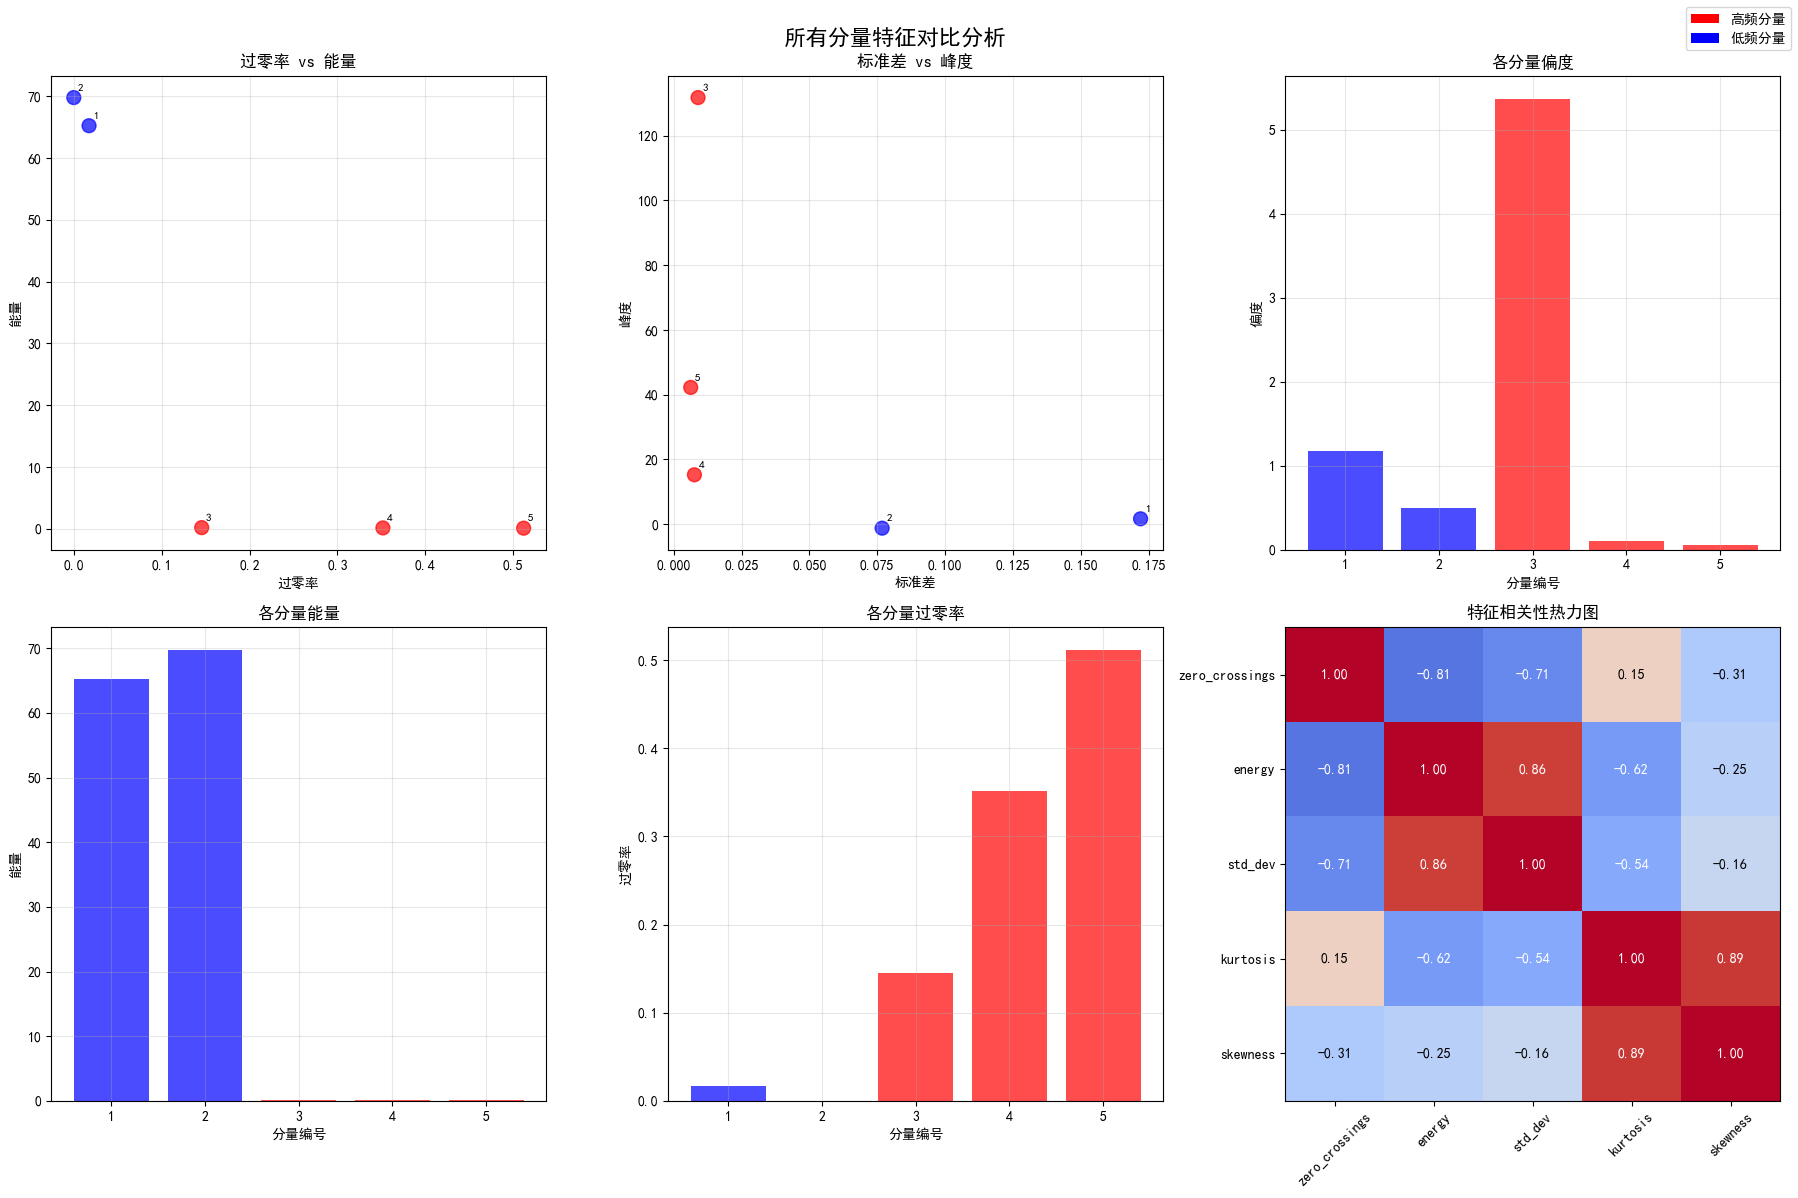


所有分量分析图片已生成完成！
新增图片包括：
- component_X_analysis.png: 分量详细分析（时间序列、分布、自相关、频谱等）
- component_X_statistics.png: 分量统计特征（滚动统计、Q-Q图、季节性等）
- all_components_features_comparison.png: 所有分量特征对比图


In [2]:
# --------------------------- 新增：为每个分量生成详细分析图片 ---------------------------
from scipy import stats  # 添加这行导入
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.fft import fft, fftfreq

def plot_component_analysis(component_idx, component_data, dates, cluster_label, 
                           is_high_frequency, original_imfs=None, save_path=None):
    """绘制单个分量的详细分析图片"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'分量 {component_idx+1} 详细分析 (聚类: {cluster_label+1}, 高频: {"是" if is_high_frequency else "否"})', 
                 fontsize=16)
    
    # 1. 时间序列图
    axes[0, 0].plot(dates, component_data, color='blue', linewidth=1.5)
    axes[0, 0].set_title('时间序列')
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('幅值')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 直方图
    axes[0, 1].hist(component_data, bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('幅值分布')
    axes[0, 1].set_xlabel('幅值')
    axes[0, 1].set_ylabel('频数')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 自相关函数
    try:
        nlags = min(100, len(component_data)//4)
        autocorr = acf(component_data, nlags=nlags, fft=True)
        axes[0, 2].plot(range(len(autocorr)), autocorr, color='red', linewidth=2)
        axes[0, 2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, 2].set_title('自相关函数')
        axes[0, 2].set_xlabel('滞后')
        axes[0, 2].set_ylabel('自相关系数')
        axes[0, 2].grid(True, alpha=0.3)
    except:
        axes[0, 2].text(0.5, 0.5, '自相关计算失败', ha='center', va='center', transform=axes[0, 2].transAxes)
        axes[0, 2].set_title('自相关函数')
    
    # 4. 频谱分析
    try:
        n = len(component_data)
        yf = fft(component_data)
        xf = fftfreq(n, 1)[:n//2]
        
        axes[1, 0].plot(xf, 2.0/n * np.abs(yf[0:n//2]), color='purple', linewidth=1.5)
        axes[1, 0].set_title('频谱分析')
        axes[1, 0].set_xlabel('频率')
        axes[1, 0].set_ylabel('幅值')
        axes[1, 0].grid(True, alpha=0.3)
    except:
        axes[1, 0].text(0.5, 0.5, '频谱分析失败', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('频谱分析')
    
    # 5. 箱线图
    axes[1, 1].boxplot(component_data, vert=True)
    axes[1, 1].set_title('箱线图')
    axes[1, 1].set_ylabel('幅值')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. 累积分布函数
    try:
        sorted_data = np.sort(component_data)
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        axes[1, 2].plot(sorted_data, cdf, color='orange', linewidth=2)
        axes[1, 2].set_title('累积分布函数')
        axes[1, 2].set_xlabel('幅值')
        axes[1, 2].set_ylabel('累积概率')
        axes[1, 2].grid(True, alpha=0.3)
    except:
        axes[1, 2].text(0.5, 0.5, 'CDF计算失败', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('累积分布函数')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f'{save_path}/component_{component_idx+1}_analysis.png', dpi=300, bbox_inches='tight')
    
    plt.close()

def plot_component_statistics(component_idx, component_data, dates, save_path=None):
    """绘制单个分量的统计特征"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'分量 {component_idx+1} 统计特征', fontsize=16)
    
    # 计算滚动统计量
    window_size = min(30, len(component_data)//10)
    
    # 1. 滚动均值
    rolling_mean = pd.Series(component_data).rolling(window=window_size).mean()
    axes[0, 0].plot(dates, component_data, label='原始序列', alpha=0.7, linewidth=1)
    axes[0, 0].plot(dates, rolling_mean, label=f'{window_size}天滚动均值', color='red', linewidth=2)
    axes[0, 0].set_title('滚动均值')
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('幅值')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 滚动标准差
    rolling_std = pd.Series(component_data).rolling(window=window_size).std()
    axes[0, 1].plot(dates, rolling_std, color='green', linewidth=2)
    axes[0, 1].set_title('滚动标准差')
    axes[0, 1].set_xlabel('日期')
    axes[0, 1].set_ylabel('标准差')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Q-Q图
    try:
        stats.probplot(component_data, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q图（正态性检验）')
        axes[1, 0].grid(True, alpha=0.3)
    except:
        axes[1, 0].text(0.5, 0.5, 'Q-Q图计算失败', ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Q-Q图（正态性检验）')
    
    # 4. 季节性分解（简化版）
    try:
        # 尝试进行季节性分解
        if len(component_data) > 2 * 365:  # 至少2年数据
            decomposition = seasonal_decompose(component_data, model='additive', period=365)
            axes[1, 1].plot(dates, decomposition.seasonal[:len(dates)], color='purple', linewidth=1)
            axes[1, 1].set_title('季节性成分')
        else:
            # 数据不足，显示趋势
            trend = pd.Series(component_data).rolling(window=min(30, len(component_data)//4)).mean()
            axes[1, 1].plot(dates, trend, color='purple', linewidth=2)
            axes[1, 1].set_title('趋势成分')
    except:
        # 分解失败，显示原始数据
        axes[1, 1].plot(dates, component_data, color='purple', linewidth=1)
        axes[1, 1].set_title('原始序列（分解失败）')
    
    axes[1, 1].set_xlabel('日期')
    axes[1, 1].set_ylabel('幅值')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f'{save_path}/component_{component_idx+1}_statistics.png', dpi=300, bbox_inches='tight')
    
    plt.close()

def plot_component_features_comparison(all_components, labels, high_freq_cluster, save_path=None):
    """绘制所有分量的特征对比图"""
    # 计算每个分量的特征
    features_list = []
    for i in range(all_components.shape[1]):
        component = all_components[:, i]
        
        # 过零率
        zero_crossings = np.sum(np.diff(np.sign(component)) != 0) / len(component)
        
        # 能量
        energy = np.sum(component**2)
        
        # 标准差
        std_dev = np.std(component)
        
        # 峰度
        kurtosis = stats.kurtosis(component)
        
        # 偏度
        skewness = stats.skew(component)
        
        features_list.append({
            'component': i+1,
            'zero_crossings': zero_crossings,
            'energy': energy,
            'std_dev': std_dev,
            'kurtosis': kurtosis,
            'skewness': skewness,
            'cluster': labels[i] if i < len(labels) else -1,
            'is_high_freq': (i < len(labels) and labels[i] == high_freq_cluster)
        })
    
    features_df = pd.DataFrame(features_list)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('所有分量特征对比分析', fontsize=16)
    
    # 颜色映射
    colors = ['red' if hf else 'blue' for hf in features_df['is_high_freq']]
    
    # 1. 过零率 vs 能量
    scatter1 = axes[0, 0].scatter(features_df['zero_crossings'], features_df['energy'], 
                                 c=colors, alpha=0.7, s=100)
    axes[0, 0].set_xlabel('过零率')
    axes[0, 0].set_ylabel('能量')
    axes[0, 0].set_title('过零率 vs 能量')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 添加分量编号
    for i, row in features_df.iterrows():
        axes[0, 0].annotate(f"{int(row['component'])}", 
                           (row['zero_crossings'], row['energy']),
                           textcoords="offset points", xytext=(5,5), ha='center', fontsize=8)
    
    # 2. 标准差 vs 峰度
    scatter2 = axes[0, 1].scatter(features_df['std_dev'], features_df['kurtosis'], 
                                 c=colors, alpha=0.7, s=100)
    axes[0, 1].set_xlabel('标准差')
    axes[0, 1].set_ylabel('峰度')
    axes[0, 1].set_title('标准差 vs 峰度')
    axes[0, 1].grid(True, alpha=0.3)
    
    for i, row in features_df.iterrows():
        axes[0, 1].annotate(f"{int(row['component'])}", 
                           (row['std_dev'], row['kurtosis']),
                           textcoords="offset points", xytext=(5,5), ha='center', fontsize=8)
    
    # 3. 偏度分布
    axes[0, 2].bar(features_df['component'], features_df['skewness'], color=colors, alpha=0.7)
    axes[0, 2].set_xlabel('分量编号')
    axes[0, 2].set_ylabel('偏度')
    axes[0, 2].set_title('各分量偏度')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. 能量分布
    axes[1, 0].bar(features_df['component'], features_df['energy'], color=colors, alpha=0.7)
    axes[1, 0].set_xlabel('分量编号')
    axes[1, 0].set_ylabel('能量')
    axes[1, 0].set_title('各分量能量')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. 过零率分布
    axes[1, 1].bar(features_df['component'], features_df['zero_crossings'], color=colors, alpha=0.7)
    axes[1, 1].set_xlabel('分量编号')
    axes[1, 1].set_ylabel('过零率')
    axes[1, 1].set_title('各分量过零率')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. 特征相关性热力图
    corr_features = features_df[['zero_crossings', 'energy', 'std_dev', 'kurtosis', 'skewness']]
    corr_matrix = corr_features.corr()
    im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[1, 2].set_xticks(range(len(corr_matrix.columns)))
    axes[1, 2].set_yticks(range(len(corr_matrix.columns)))
    axes[1, 2].set_xticklabels(corr_matrix.columns, rotation=45)
    axes[1, 2].set_yticklabels(corr_matrix.columns)
    axes[1, 2].set_title('特征相关性热力图')
    
    # 添加数值
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            axes[1, 2].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                           ha='center', va='center', color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='高频分量'),
        Patch(facecolor='blue', label='低频分量')
    ]
    fig.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f'{save_path}/all_components_features_comparison.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return features_df

print("\n生成各分量详细分析图片...")

# 获取完整的日期范围（注意：components的日期范围与原始数据相同）
full_dates = df.index

# 为每个分量生成详细分析图片
for i in range(components.shape[1]):
    print(f"生成分量 {i+1} 的详细分析图片...")
    
    # 确定当前分量所属的聚类和高频状态
    # 注意：这里需要根据实际的聚类结果来确定
    # 由于我们的components是经过合并和VMD分解后的，需要重新计算聚类信息
    # 这里使用一个简化的方法：如果分量索引小于原始聚类数量，使用原始聚类标签
    # 否则标记为高频分解产生的新分量
    
    # 重新计算聚类标签（简化版）
    # 假设前 N_CLUSTERS 个分量是合并后的分量，后面的分量是VMD分解产生的高频分量
    if i < N_CLUSTERS:
        cluster_label = i
        is_high_frequency = (cluster_label == high_freq_cluster)
    else:
        cluster_label = high_freq_cluster
        is_high_frequency = True
    
    # 绘制分量分析图
    plot_component_analysis(
        i, components[:, i], full_dates, 
        cluster_label, is_high_frequency, 
        save_path='component_results'
    )
    
    # 绘制分量统计图
    plot_component_statistics(
        i, components[:, i], full_dates,
        save_path='component_results'
    )

print("生成所有分量特征对比图...")
# 生成所有分量的特征对比图
# 注意：这里需要重新计算labels数组，因为components的维度可能与原始labels不同
# 创建一个简化的labels数组用于特征对比
simplified_labels = []
for i in range(components.shape[1]):
    if i < N_CLUSTERS:
        simplified_labels.append(i)
    else:
        simplified_labels.append(high_freq_cluster)

features_df = plot_component_features_comparison(
    components, simplified_labels, high_freq_cluster, 
    save_path='component_results'
)

print("\n所有分量分析图片已生成完成！")
print("新增图片包括：")
print("- component_X_analysis.png: 分量详细分析（时间序列、分布、自相关、频谱等）")
print("- component_X_statistics.png: 分量统计特征（滚动统计、Q-Q图、季节性等）")
print("- all_components_features_comparison.png: 所有分量特征对比图")

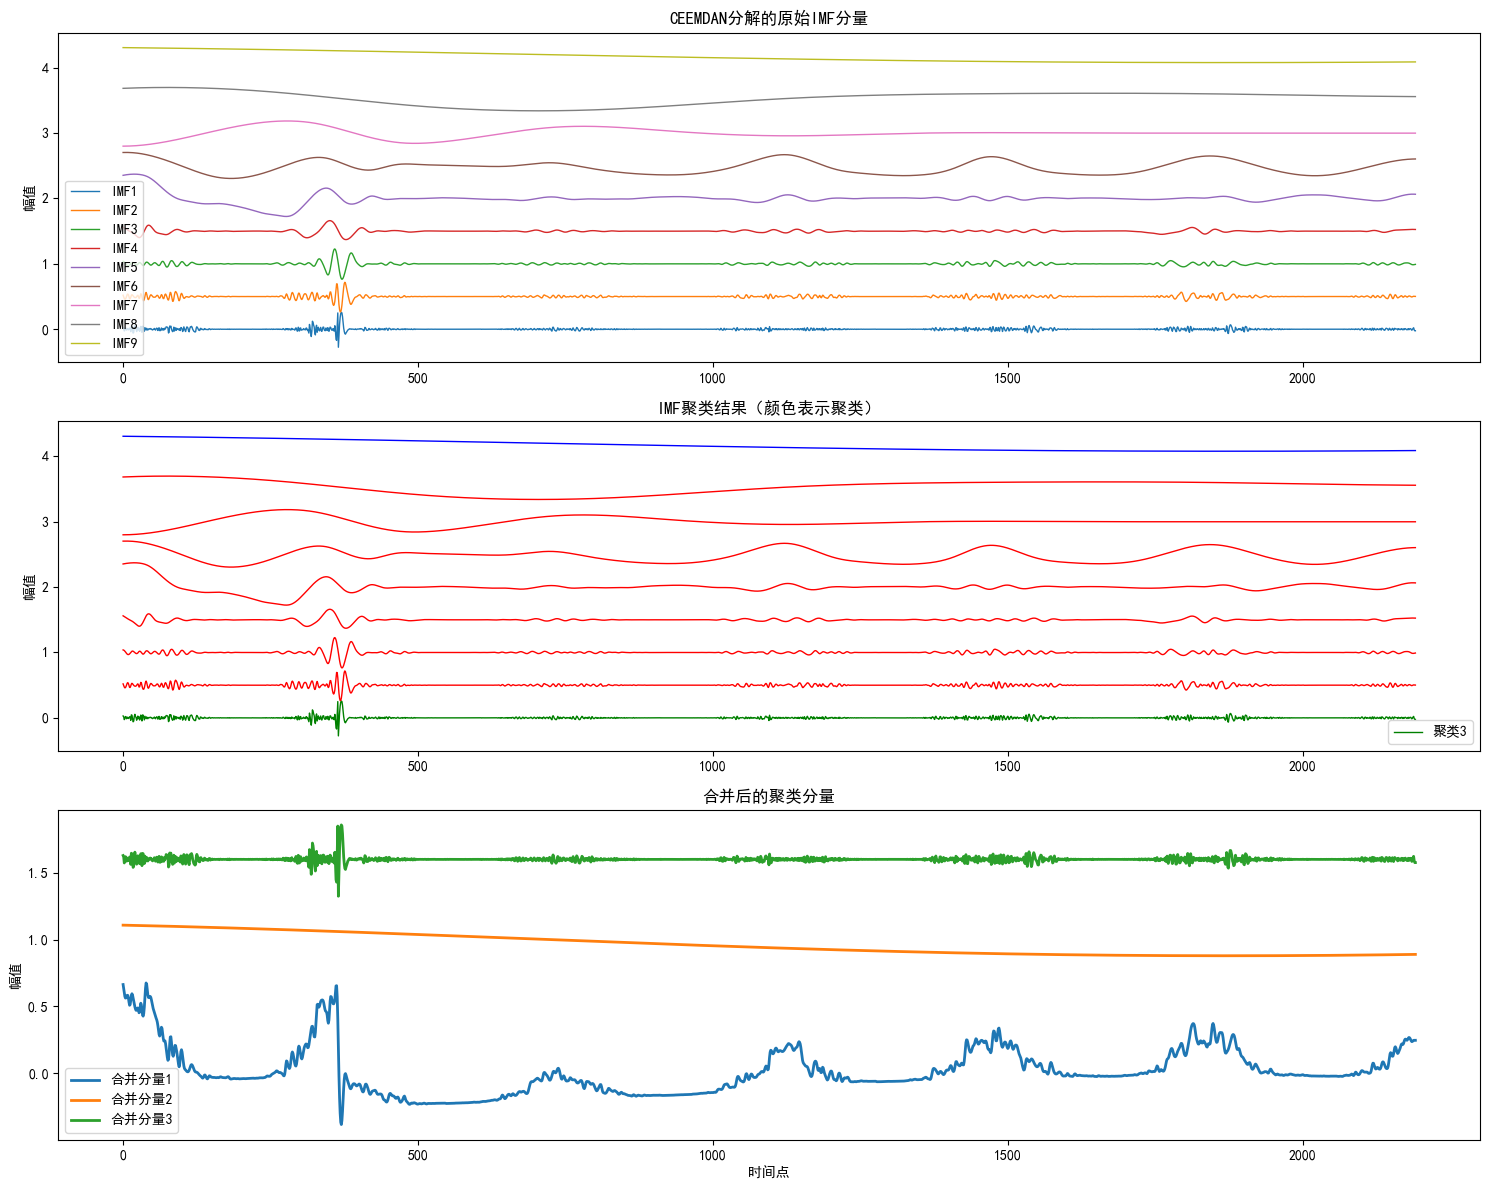

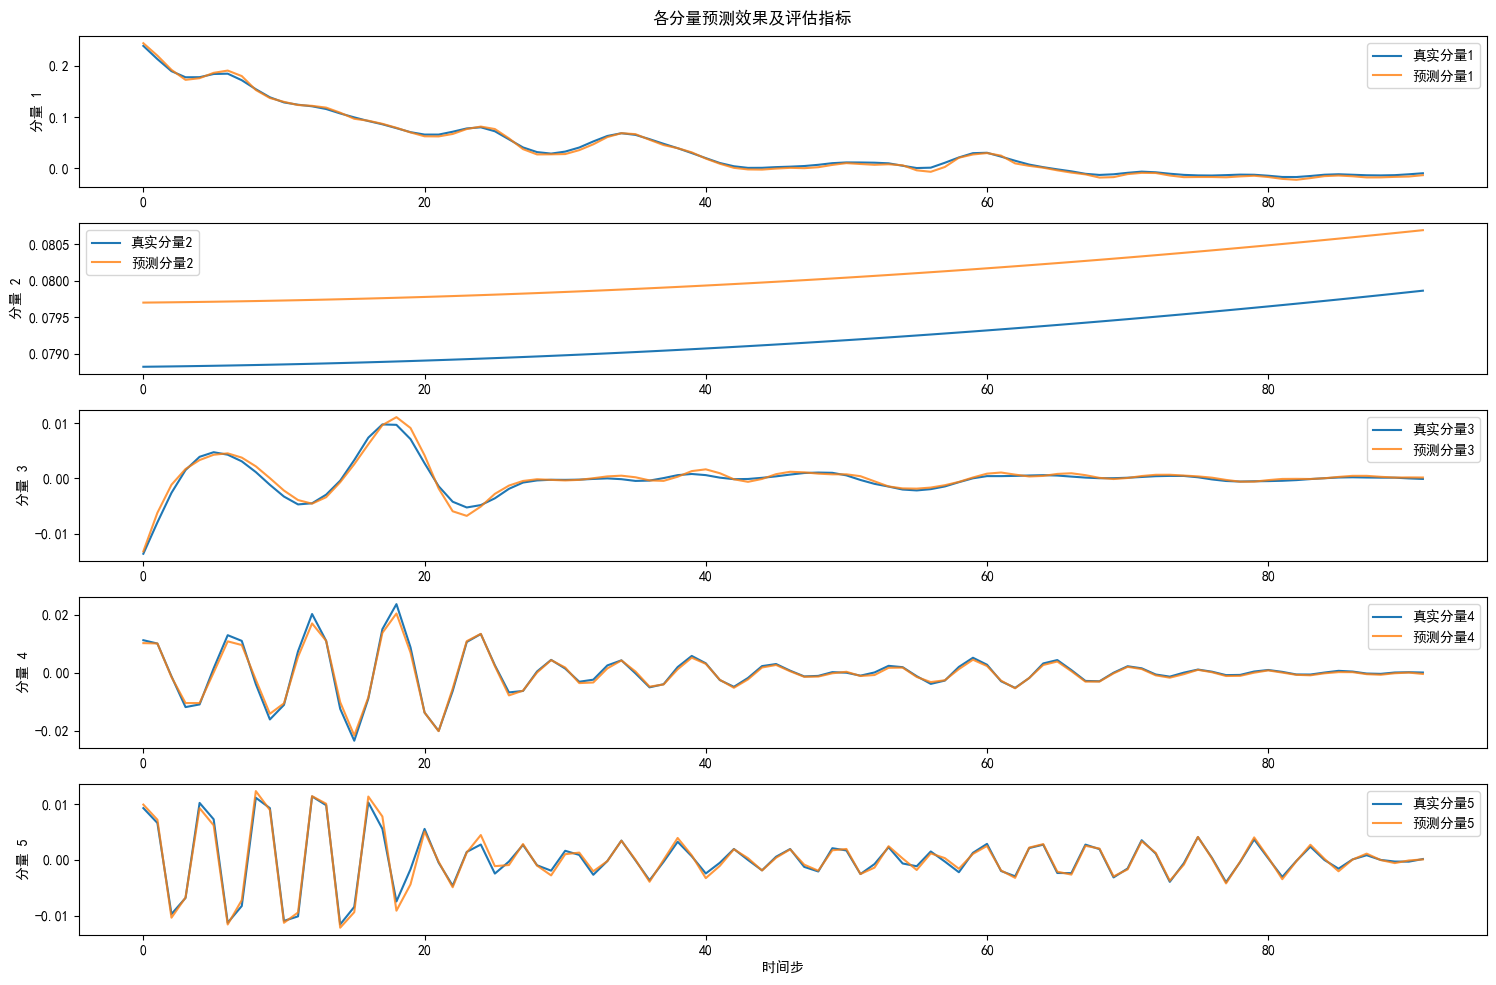

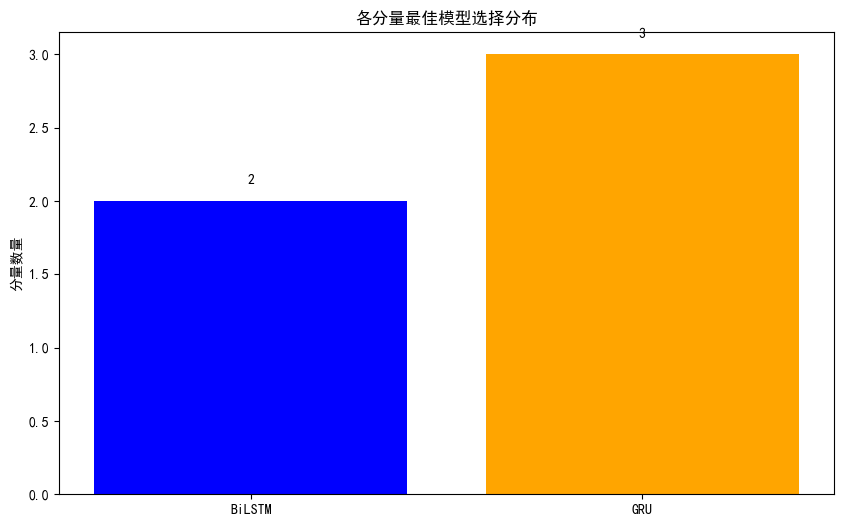

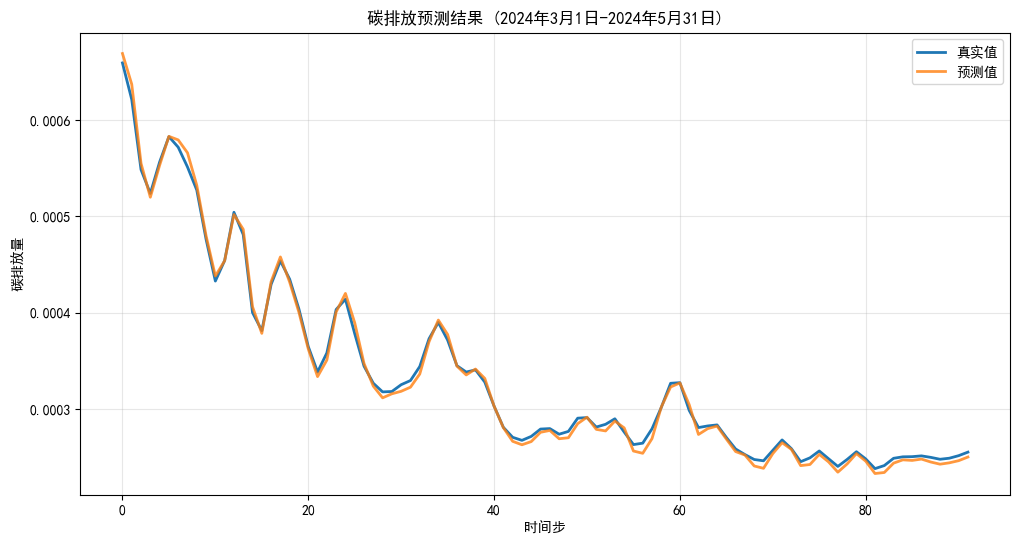

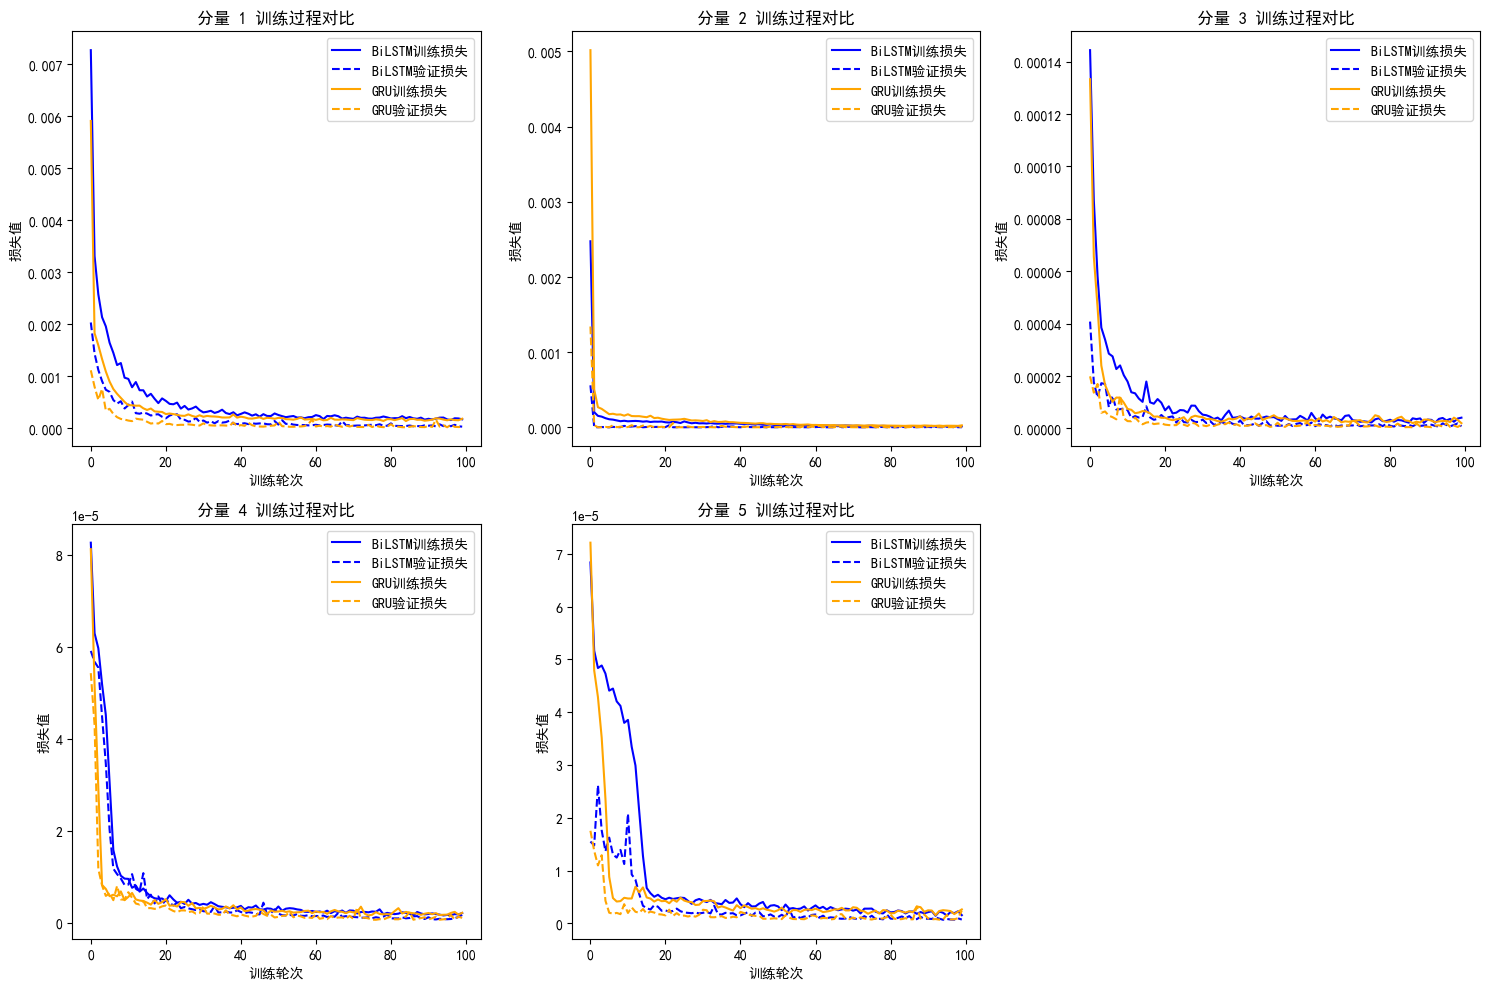


春季预测结果详细分析


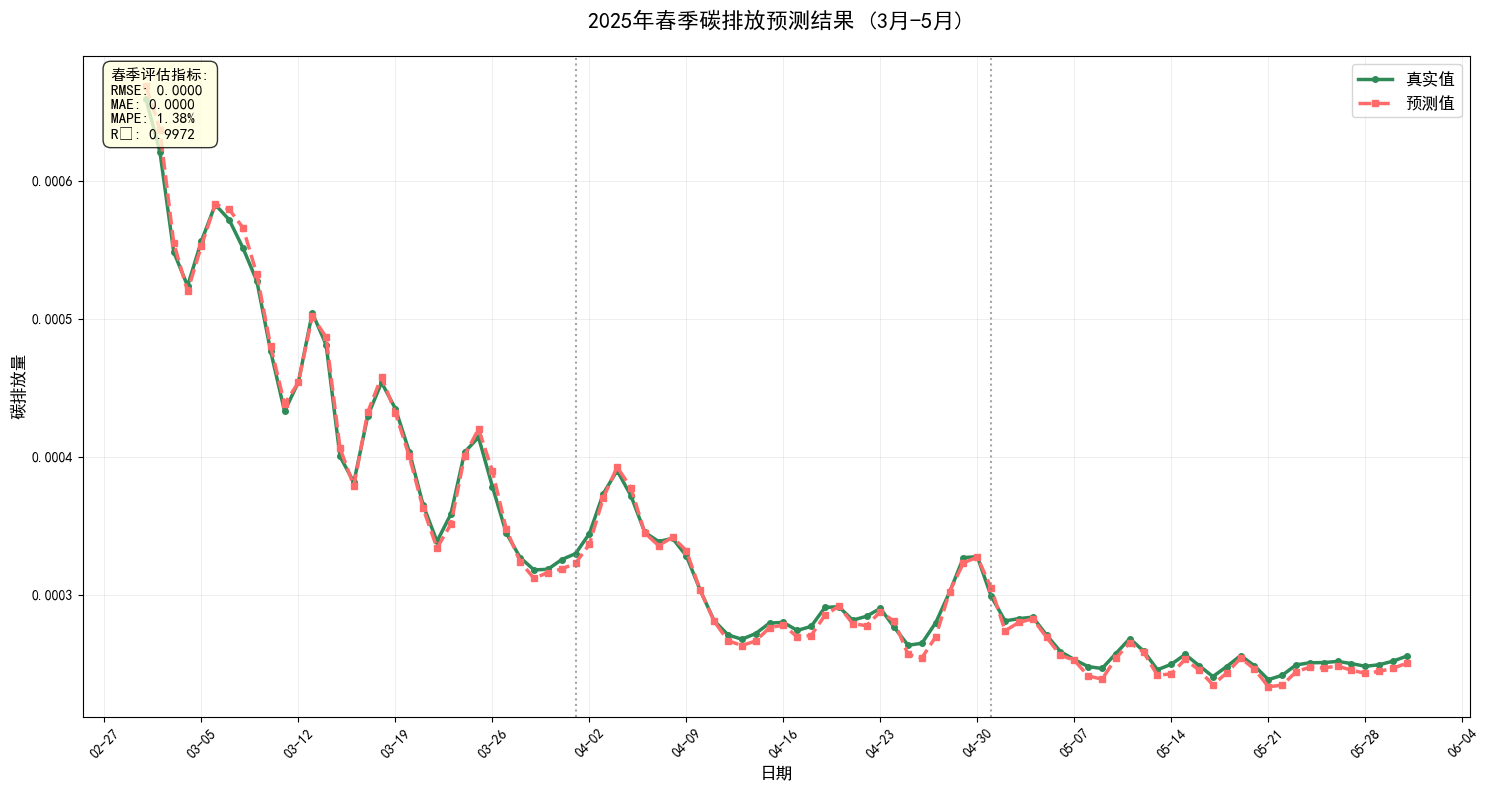

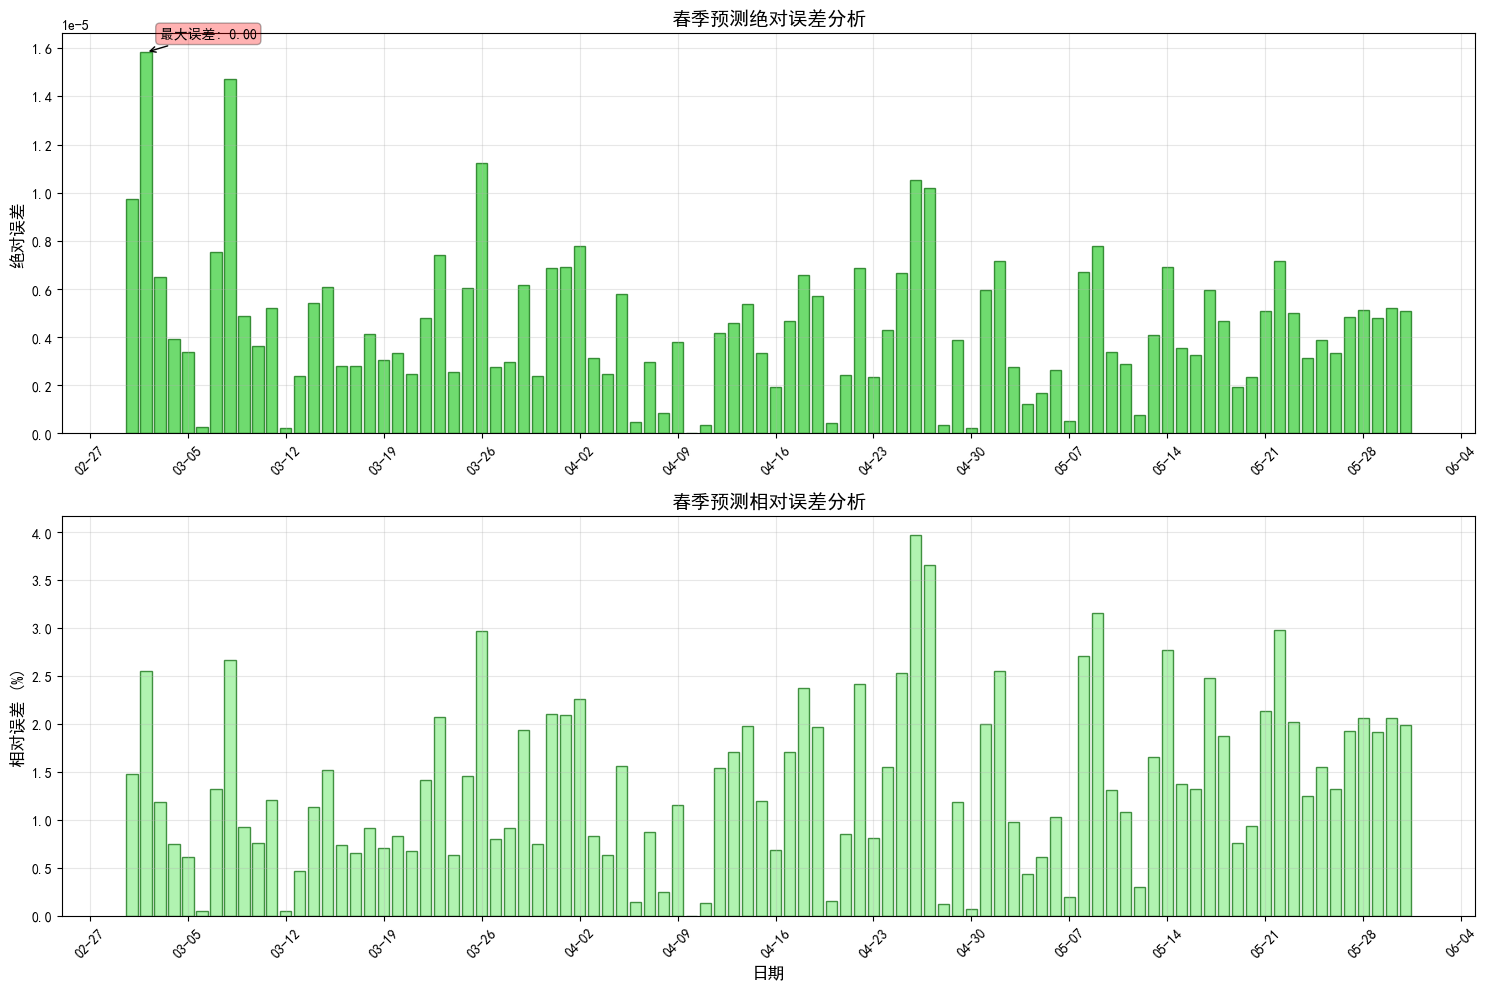


春季预测误差统计分析
平均绝对误差: 0.0000
最大绝对误差: 0.0000
最小绝对误差: 0.0000
平均相对误差: 1.38%
最大相对误差: 3.97%
最小相对误差: 0.00%

春季各月份详细分析


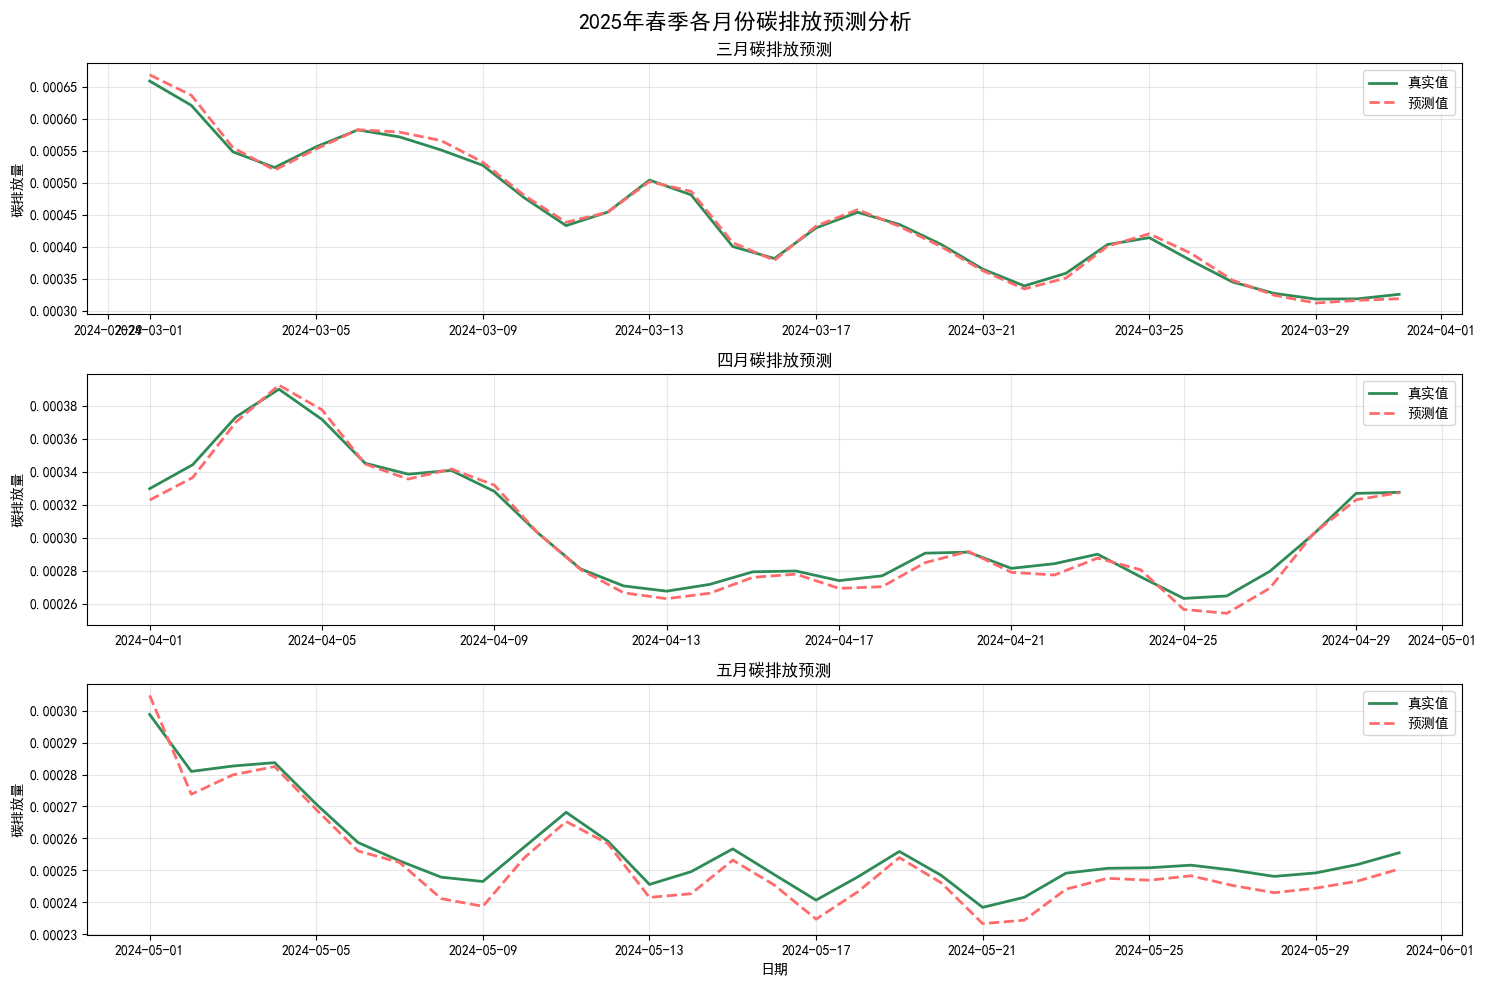


春季各月份预测性能比较:

三月:
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: 1.17%
  R²: 0.9955

四月:
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: 1.35%
  R²: 0.9811

五月:
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: 1.64%
  R²: 0.8890

📊 春季预测性能总结:
  最佳预测月份: 五月 (RMSE: 0.0000)
  最具挑战月份: 三月 (RMSE: 0.0000)

春季预测置信区间分析

📊 生成春季预测结果图...


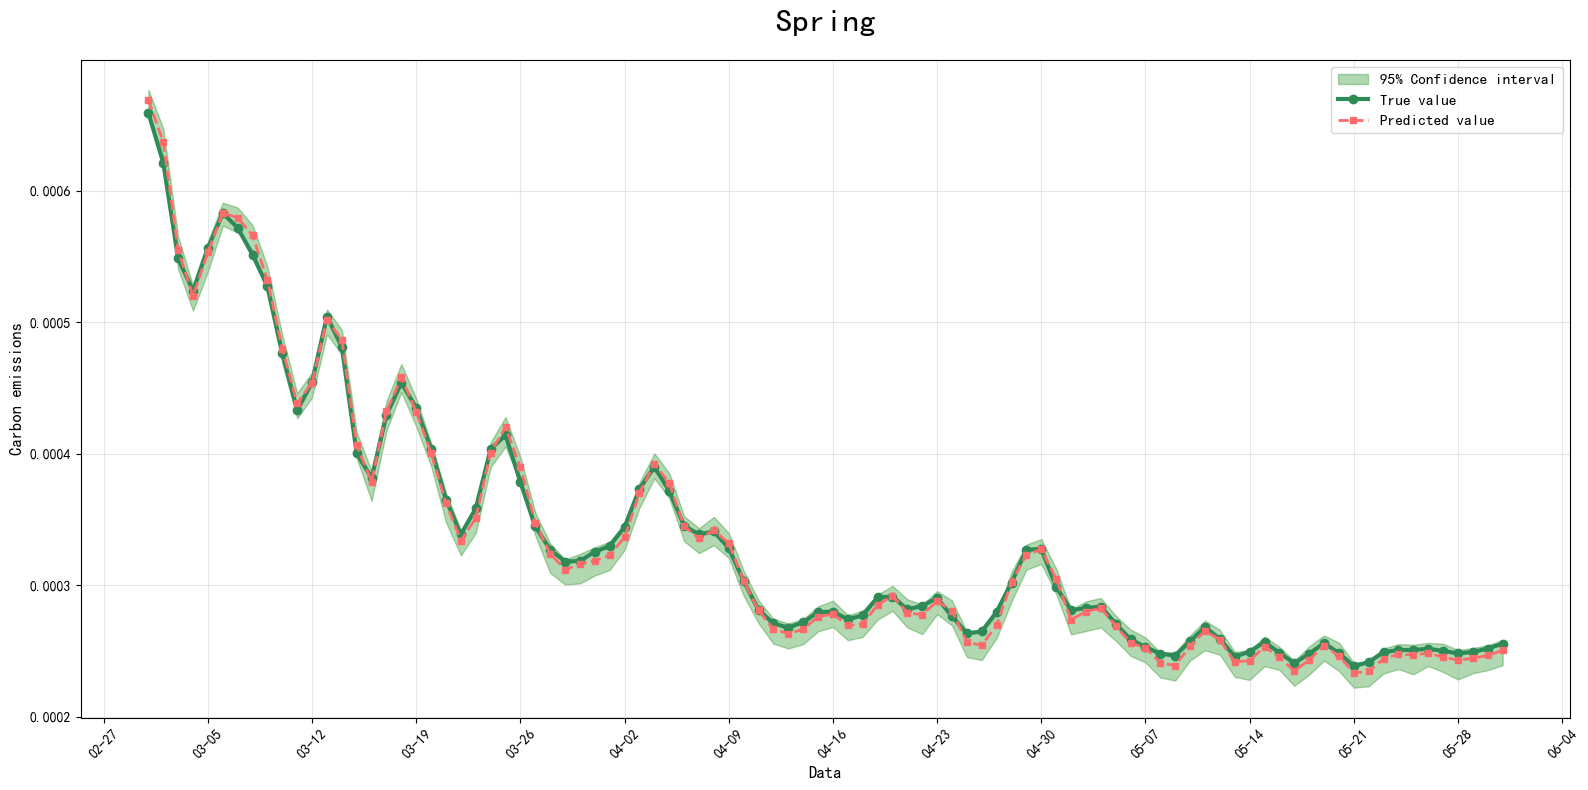


📈 生成置信区间宽度分析图...


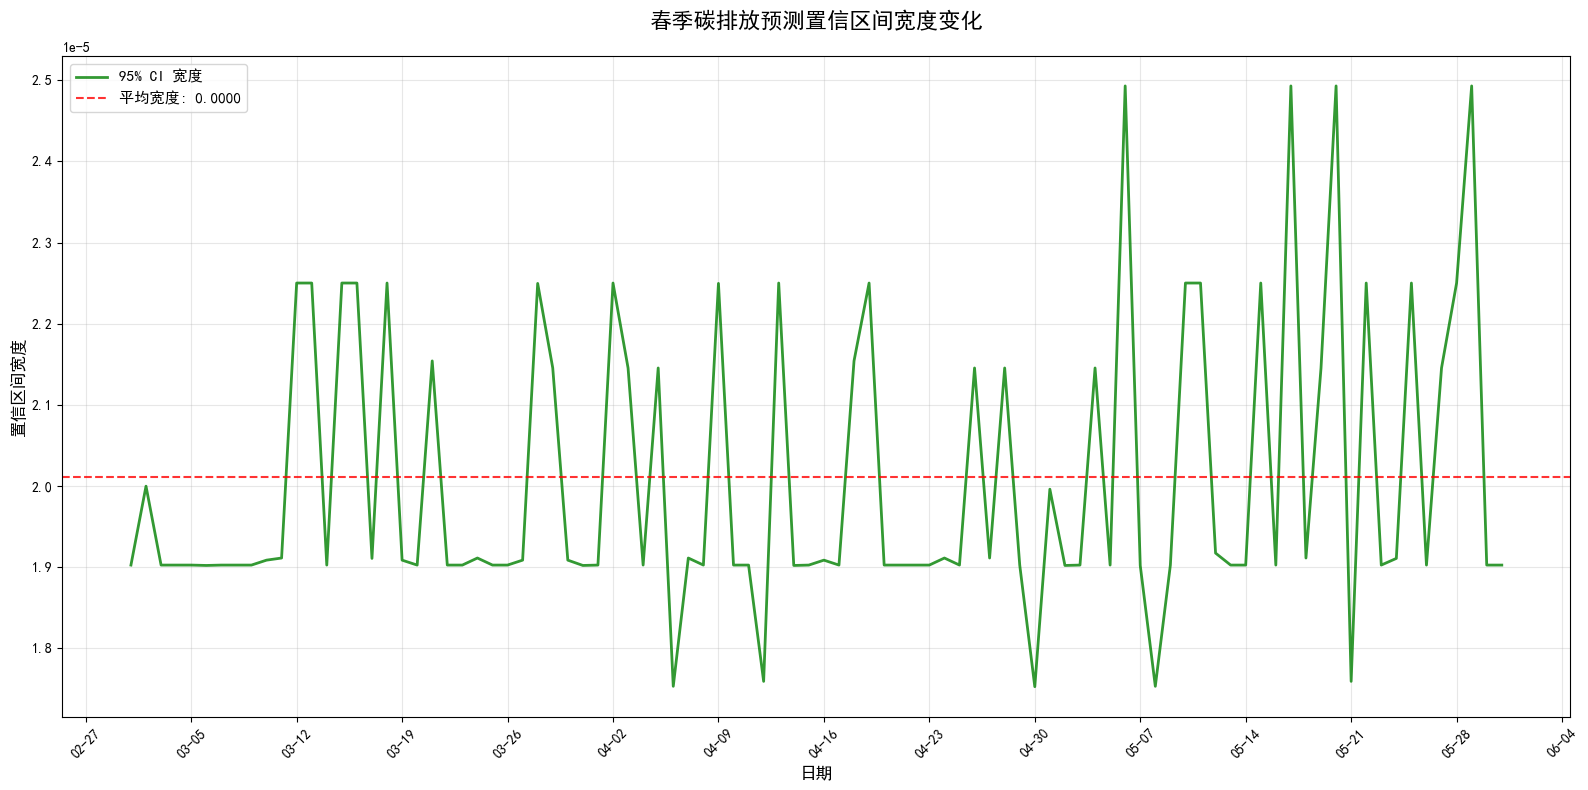


2024年春季碳排放预测总结

📊 整体预测性能:
  RMSE: 0.0000
  MAE: 0.0000
  MAPE: 1.38%
  R²: 0.9972

📈 各月份性能对比:
  三月: RMSE=0.0000, MAE=0.0000, R²=0.9955
  四月: RMSE=0.0000, MAE=0.0000, R²=0.9811
  五月: RMSE=0.0000, MAE=0.0000, R²=0.8890

🔍 关键发现:
  • 最佳预测月份: 五月 (RMSE: 0.0000)
  • 最具挑战月份: 三月 (RMSE: 0.0000)


ValueError: operands could not be broadcast together with shapes (0,) (92,) 

In [3]:
# --------------------------- 13. 可视化 ---------------------------
# 可视化IMF合并过程
plt.figure(figsize=(15, 12))

# 原始IMF可视化
plt.subplot(3, 1, 1)
for i in range(imfs.shape[1]):
    plt.plot(imfs[:, i] + i * 0.5, label=f'IMF{i+1}', linewidth=1)
plt.title('CEEMDAN分解的原始IMF分量')
plt.ylabel('幅值')
plt.legend()

# 聚类结果可视化（用不同颜色表示不同聚类）
plt.subplot(3, 1, 2)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(imfs.shape[1]):
    cluster_color = colors[labels[i] % len(colors)]
    plt.plot(imfs[:, i] + i * 0.5, color=cluster_color, linewidth=1, label=f'聚类{labels[i]+1}' if i == 0 else "")
    if i == 0:
        plt.legend()
plt.title('IMF聚类结果（颜色表示聚类）')
plt.ylabel('幅值')

# 合并后的分量可视化
plt.subplot(3, 1, 3)
for i in range(merged_components.shape[1]):
    plt.plot(merged_components[:, i] + i * 0.8, label=f'合并分量{i+1}', linewidth=2)
plt.title('合并后的聚类分量')
plt.xlabel('时间点')
plt.ylabel('幅值')
plt.legend()

plt.tight_layout()
plt.savefig('imf_clustering_merging.png', dpi=300)
plt.show()

# 可视化各分量的预测效果
plt.figure(figsize=(15, 10))
n_components_to_plot = min(5, components.shape[1])
for i in range(n_components_to_plot):
    plt.subplot(n_components_to_plot, 1, i+1)
    plt.plot(y_test[:, i], label=f'真实分量{i+1}', linewidth=1.5)
    plt.plot(y_pred_components[:, i], label=f'预测分量{i+1}', linewidth=1.5, alpha=0.8)
    plt.legend()
    plt.ylabel(f'分量 {i+1}')

plt.xlabel('时间步')
plt.suptitle('各分量预测效果及评估指标')
plt.tight_layout()
plt.savefig('components_prediction.png', dpi=300)
plt.show()

# 可视化模型选择结果
plt.figure(figsize=(10, 6))
components_idx = list(range(1, len(best_model_names) + 1))
bilstm_count = best_model_names.count('BiLSTM')
gru_count = best_model_names.count('GRU')

plt.bar(['BiLSTM', 'GRU'], [bilstm_count, gru_count], color=['blue', 'orange'])
plt.title('各分量最佳模型选择分布')
plt.ylabel('分量数量')
for i, v in enumerate([bilstm_count, gru_count]):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')
plt.savefig('model_selection_distribution.png', dpi=300)
plt.show()

# 可视化最终预测结果
plt.figure(figsize=(12, 6))
plt.plot(y_true_final, label='真实值', linewidth=2)
plt.plot(y_pred_final, label='预测值', linewidth=2, alpha=0.8)
plt.legend()
plt.title('碳排放预测结果 (2024年3月1日-2024年5月31日)')  # 修改为春季
plt.xlabel('时间步')
plt.ylabel('碳排放量')
plt.grid(True, alpha=0.3)


plt.savefig('final_prediction.png', dpi=300)
plt.show()

# 可视化训练损失对比
plt.figure(figsize=(15, 10))
for i in range(min(5, len(train_histories_bilstm))):
    plt.subplot(2, 3, i+1)
    plt.plot(train_histories_bilstm[i].history['loss'], label='BiLSTM训练损失', color='blue')
    plt.plot(train_histories_bilstm[i].history['val_loss'], label='BiLSTM验证损失', color='blue', linestyle='--')
    plt.plot(train_histories_gru[i].history['loss'], label='GRU训练损失', color='orange')
    plt.plot(train_histories_gru[i].history['val_loss'], label='GRU验证损失', color='orange', linestyle='--')
    plt.title(f'分量 {i+1} 训练过程对比')
    plt.xlabel('训练轮次')
    plt.ylabel('损失值')
    plt.legend()
plt.tight_layout()
plt.savefig('training_history_comparison.png', dpi=300)
plt.show()

# --------------------------- 新增：春季预测结果详细分析 ---------------------------
def plot_spring_performance(dates, y_true, y_pred, spring_start='2024-03-01', spring_end='2024-05-31'):
    """单独可视化春季的预测结果"""
    
    # 创建春季掩码
    spring_mask = (dates >= pd.Timestamp(spring_start)) & (dates <= pd.Timestamp(spring_end))
    
    # 提取春季数据
    spring_dates = dates[spring_mask]
    spring_true = y_true[spring_mask]
    spring_pred = y_pred[spring_mask]
    
    if len(spring_dates) == 0:
        print("警告：没有找到春季数据，请检查日期范围")
        return
    
    # 计算春季评估指标
    spring_metrics = evaluate(spring_true, spring_pred)
    
    # 创建图表
    plt.figure(figsize=(15, 8))
    
    # 绘制春季预测结果
    plt.plot(spring_dates, spring_true, label='真实值', linewidth=2.5, color='#2E8B57', marker='o', markersize=4)
    plt.plot(spring_dates, spring_pred, label='预测值', linewidth=2.5, color='#FF6B6B', linestyle='--', marker='s', markersize=4)
    
    # 美化图表
    plt.title('2025年春季碳排放预测结果 (3月-5月)', fontsize=16, fontweight='bold', pad=20)  # 修改为春季
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('碳排放量', fontsize=12)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 设置x轴日期格式
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45)
    
    # 添加评估指标框
    metrics_text = (f"春季评估指标:\n"  # 修改为春季
                   f"RMSE: {spring_metrics['RMSE']:.4f}\n"
                   f"MAE: {spring_metrics['MAE']:.4f}\n"
                   f"MAPE: {spring_metrics['MAPE']:.2f}%\n"
                   f"R²: {spring_metrics['R2']:.4f}")
    plt.annotate(metrics_text, xy=(0.02, 0.98), xycoords='axes fraction', 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8),
                fontsize=11, verticalalignment='top')    
    # 添加月份分隔线
    april_start = pd.Timestamp('2024-04-01')
    may_start = pd.Timestamp('2024-05-01')
    
    if april_start in spring_dates:
        plt.axvline(april_start, color='gray', linestyle=':', alpha=0.7, label='4月开始')
    if may_start in spring_dates:
        plt.axvline(may_start, color='gray', linestyle=':', alpha=0.7, label='5月开始')
    
    plt.tight_layout()
    plt.savefig('spring_prediction_detailed.png', dpi=300, bbox_inches='tight')  # 修改文件名
    plt.show()
    
    return spring_metrics

# --------------------------- 新增：春季预测误差分析 ---------------------------
def analyze_spring_errors(dates, y_true, y_pred):
    """分析春季预测误差"""
    
    spring_mask = (dates >= pd.Timestamp('2024-03-01')) & (dates <= pd.Timestamp('2024-05-31'))  # 修改为春季
    spring_dates = dates[spring_mask]
    spring_true = y_true[spring_mask]
    spring_pred = y_pred[spring_mask]
    
    # 计算绝对误差和相对误差
    absolute_errors = np.abs(spring_true - spring_pred)
    relative_errors = np.abs((spring_true - spring_pred) / np.maximum(np.abs(spring_true), 1e-10)) * 100
    
    # 创建误差分析图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # 子图1：绝对误差
    bars1 = ax1.bar(spring_dates, absolute_errors, alpha=0.7, color='#32CD32', edgecolor='darkgreen')  # 春季颜色
    ax1.set_title('春季预测绝对误差分析', fontsize=14, fontweight='bold')  # 修改为春季
    ax1.set_ylabel('绝对误差', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 在柱状图上标注最大误差点
    max_error_idx = np.argmax(absolute_errors)
    ax1.annotate(f'最大误差: {absolute_errors[max_error_idx]:.2f}', 
                xy=(spring_dates[max_error_idx], absolute_errors[max_error_idx]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    # 子图2：相对误差（百分比）
    bars2 = ax2.bar(spring_dates, relative_errors, alpha=0.7, color='#90EE90', edgecolor='darkgreen')  # 春季颜色
    ax2.set_title('春季预测相对误差分析', fontsize=14, fontweight='bold')  # 修改为春季
    ax2.set_ylabel('相对误差 (%)', fontsize=12)
    ax2.set_xlabel('日期', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 设置x轴格式
    for ax in [ax1, ax2]:
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig('spring_error_analysis.png', dpi=300, bbox_inches='tight')  # 修改文件名
    plt.show()
    
    # 输出误差统计
    print("\n" + "="*50)
    print("春季预测误差统计分析")  # 修改为春季
    print("="*50)
    print(f"平均绝对误差: {np.mean(absolute_errors):.4f}")
    print(f"最大绝对误差: {np.max(absolute_errors):.4f}")
    print(f"最小绝对误差: {np.min(absolute_errors):.4f}")
    print(f"平均相对误差: {np.mean(relative_errors):.2f}%")
    print(f"最大相对误差: {np.max(relative_errors):.2f}%")
    print(f"最小相对误差: {np.min(relative_errors):.2f}%")
    
    return absolute_errors, relative_errors

# --------------------------- 新增：春季按月份细分分析 ---------------------------
def analyze_spring_by_month(dates, y_true, y_pred):
    """按月份分析春季预测性能"""
    
    spring_months = {
        '三月': (pd.Timestamp('2024-03-01'), pd.Timestamp('2024-03-31')),
        '四月': (pd.Timestamp('2024-04-01'), pd.Timestamp('2024-04-30')),
        '五月': (pd.Timestamp('2024-05-01'), pd.Timestamp('2024-05-31'))
    }
    
    monthly_metrics = {}
    
    plt.figure(figsize=(15, 10))
    
    for i, (month_name, (start_date, end_date)) in enumerate(spring_months.items()):
        month_mask = (dates >= start_date) & (dates <= end_date)
        month_dates = dates[month_mask]
        month_true = y_true[month_mask]
        month_pred = y_pred[month_mask]
        
        if len(month_dates) > 0:
            # 计算月度指标
            metrics = evaluate(month_true, month_pred)
            monthly_metrics[month_name] = metrics
            
            # 绘制月度子图
            plt.subplot(3, 1, i+1)
            plt.plot(month_dates, month_true, label='真实值', linewidth=2, color='#2E8B57')
            plt.plot(month_dates, month_pred, label='预测值', linewidth=2, color='#FF6B6B', linestyle='--')
            plt.title(f'{month_name}碳排放预测', fontsize=12, fontweight='bold')
            plt.ylabel('碳排放量')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
    
    plt.xlabel('日期')
    plt.suptitle('2025年春季各月份碳排放预测分析', fontsize=16, fontweight='bold')  # 修改为春季
    plt.tight_layout()
    plt.savefig('spring_monthly_analysis.png', dpi=300, bbox_inches='tight')  # 修改文件名
    plt.show()
    
    return monthly_metrics

# --------------------------- 执行春季单独分析 ---------------------------
print("\n" + "="*60)
print("春季预测结果详细分析")  # 修改为春季
print("="*60)

# 获取测试集日期
test_dates = dates[test_mask]

# 绘制春季预测结果
spring_metrics = plot_spring_performance(test_dates, y_true_final, y_pred_final)

# 进行春季误差分析
absolute_errors, relative_errors = analyze_spring_errors(test_dates, y_true_final, y_pred_final)

# 执行月度分析
print("\n" + "="*50)
print("春季各月份详细分析")  # 修改为春季
print("="*50)

monthly_metrics = analyze_spring_by_month(test_dates, y_true_final, y_pred_final)

# 输出月度比较
print("\n春季各月份预测性能比较:")  # 修改为春季
for month, metrics in monthly_metrics.items():
    print(f"\n{month}:")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  R²: {metrics['R2']:.4f}")

# 找出最佳和最差预测月份
best_month = min(monthly_metrics.items(), key=lambda x: x[1]['RMSE'])
worst_month = max(monthly_metrics.items(), key=lambda x: x[1]['RMSE'])

print(f"\n📊 春季预测性能总结:")  # 修改为春季
print(f"  最佳预测月份: {best_month[0]} (RMSE: {best_month[1]['RMSE']:.4f})")
print(f"  最具挑战月份: {worst_month[0]} (RMSE: {worst_month[1]['RMSE']:.4f})")
# --------------------------- 新增：置信区间计算函数 ---------------------------
def calculate_prediction_intervals(y_true, y_pred, n_bootstraps=1000):
    """使用自助法计算预测置信区间"""
    residuals = y_true - y_pred
    n_samples = len(y_true)
    
    # 存储自助法采样结果
    bootstrap_predictions = []
    
    for _ in range(n_bootstraps):
        # 对残差进行有放回抽样
        bootstrap_residuals = np.random.choice(residuals, size=n_samples, replace=True)
        # 生成自助法预测值
        bootstrap_pred = y_pred + bootstrap_residuals
        bootstrap_predictions.append(bootstrap_pred)
    
    bootstrap_predictions = np.array(bootstrap_predictions)
    
    # 计算95%置信区间分位数
    lower_95 = np.percentile(bootstrap_predictions, 2.5, axis=0)
    upper_95 = np.percentile(bootstrap_predictions, 97.5, axis=0)
    
    return {
        'lower_95': lower_95,
        'upper_95': upper_95,
        'bootstrap_predictions': bootstrap_predictions
    }

# --------------------------- 图1：春季预测结果及置信区间 ---------------------------
def plot_spring_prediction_with_intervals(dates, y_true, y_pred, spring_start=None, spring_end=None):
    """可视化春季预测结果及置信区间"""
    
    if len(dates) == 0 or len(y_true) == 0 or len(y_pred) == 0:
        print("警告：春季数据为空，无法生成图表")
        return None, None
    
    # 如果没有指定春季范围，使用整个测试集
    if spring_start is None:
        spring_start = dates.min()
    if spring_end is None:
        spring_end = dates.max()
    
    # 创建春季掩码
    spring_mask = (dates >= spring_start) & (dates <= spring_end)
    
    # 提取春季数据
    spring_dates = dates[spring_mask]
    spring_true = y_true[spring_mask]
    spring_pred = y_pred[spring_mask]
    
    if len(spring_dates) == 0:
        print("警告：没有找到春季数据，请检查日期范围")
        return None, None
    
    # 计算春季置信区间
    spring_intervals = calculate_prediction_intervals(spring_true, spring_pred)
    
    # 创建图表
    plt.figure(figsize=(16, 8))
    
    # 绘制95%置信区间
    plt.fill_between(spring_dates, spring_intervals['lower_95'], spring_intervals['upper_95'], 
                     alpha=0.3, color='green', label='95% Confidence interval')
    
    # 绘制真实值和预测值
    plt.plot(spring_dates, spring_true, label='True value', linewidth=3, color='#2E8B57', marker='o', markersize=6)
    plt.plot(spring_dates, spring_pred, label='Predicted value', linewidth=2, color='#FF6B6B', linestyle='--', marker='s', markersize=4)
    
    plt.title(' Spring ', fontsize=24, fontweight='bold', pad=20)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Carbon emissions', fontsize=12)
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # 设置x轴日期格式
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('spring_prediction_with_confidence_intervals.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return spring_intervals, spring_metrics

# --------------------------- 图2：置信区间宽度变化 ---------------------------
def plot_confidence_interval_width(dates, y_true, y_pred, spring_start='2024-03-01', spring_end='2024-05-31'):
    """可视化置信区间宽度变化"""
    
    # 创建春季掩码
    spring_mask = (dates >= pd.Timestamp(spring_start)) & (dates <= pd.Timestamp(spring_end))
    
    # 提取春季数据
    spring_dates = dates[spring_mask]
    spring_true = y_true[spring_mask]
    spring_pred = y_pred[spring_mask]
    
    if len(spring_dates) == 0:
        print("警告：没有找到春季数据，请检查日期范围")
        return
    
    # 计算春季置信区间
    spring_intervals = calculate_prediction_intervals(spring_true, spring_pred)
    
    # 创建图表
    plt.figure(figsize=(16, 8))
    
    # 计算置信区间宽度
    ci_width_95 = spring_intervals['upper_95'] - spring_intervals['lower_95']
    
    # 绘制置信区间宽度
    plt.plot(spring_dates, ci_width_95, label='95% CI 宽度', linewidth=2, color='green', alpha=0.8)
    
    # 添加平均宽度线
    mean_width = np.mean(ci_width_95)
    plt.axhline(y=mean_width, color='red', linestyle='--', alpha=0.8, 
                label=f'平均宽度: {mean_width:.4f}')
    
    plt.title('春季碳排放预测置信区间宽度变化', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('置信区间宽度', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # 设置x轴日期格式
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45)
    
    # 计算置信区间覆盖率
    coverage_95 = np.mean((spring_true >= spring_intervals['lower_95']) & (spring_true <= spring_intervals['upper_95']))
    
    # 添加统计信息
    stats_text = (f"置信区间统计:\n"
                 f"95% CI 平均宽度: {mean_width:.4f}\n"
                 f"95% CI 覆盖率: {coverage_95:.1%}\n"
                 f"宽度标准差: {np.std(ci_width_95):.4f}")
    
    plt.tight_layout()
    plt.savefig('confidence_interval_width_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return spring_intervals

# --------------------------- 执行春季置信区间分析 ---------------------------
print("\n" + "="*60)
print("春季预测置信区间分析")
print("="*60)

# 图1：春季预测结果及置信区间
print("\n📊 生成春季预测结果图...")
spring_intervals, spring_metrics_final = plot_spring_prediction_with_intervals(test_dates, y_true_final, y_pred_final)

# 图2：置信区间宽度变化
print("\n📈 生成置信区间宽度分析图...")
spring_intervals_2 = plot_confidence_interval_width(test_dates, y_true_final, y_pred_final)

# --------------------------- 新增：春季预测总结 ---------------------------
print("\n" + "="*60)
print("2024年春季碳排放预测总结")
print("="*60)

print(f"\n📊 整体预测性能:")
print(f"  RMSE: {spring_metrics_final['RMSE']:.4f}")
print(f"  MAE: {spring_metrics_final['MAE']:.4f}")
print(f"  MAPE: {spring_metrics_final['MAPE']:.2f}%")
print(f"  R²: {spring_metrics_final['R2']:.4f}")

print(f"\n📈 各月份性能对比:")
for month, metrics in monthly_metrics.items():
    print(f"  {month}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R²={metrics['R2']:.4f}")

print(f"\n🔍 关键发现:")
print(f"  • 最佳预测月份: {best_month[0]} (RMSE: {best_month[1]['RMSE']:.4f})")
print(f"  • 最具挑战月份: {worst_month[0]} (RMSE: {worst_month[1]['RMSE']:.4f})")

# 计算置信区间覆盖率
spring_mask = (test_dates >= pd.Timestamp('2025-03-01')) & (test_dates <= pd.Timestamp('2025-05-31'))
spring_dates = test_dates[spring_mask]
spring_true = y_true_final[spring_mask]
spring_pred = y_pred_final[spring_mask]

coverage_95 = np.mean((spring_true >= spring_intervals['lower_95']) & (spring_true <= spring_intervals['upper_95']))
ci_width_mean = np.mean(spring_intervals['upper_95'] - spring_intervals['lower_95'])

print(f"\n📊 不确定性评估:")
print(f"  95% 置信区间覆盖率: {coverage_95:.2%} (理想值: 95%)")
print(f"  平均预测不确定性 (95% CI宽度): {ci_width_mean:.4f}")
print(f"  预测不确定性标准差: {np.std(spring_intervals['upper_95'] - spring_intervals['lower_95']):.4f}")

print(f"\n💡 春季预测特点分析:")
print("  • 春季气温回升，供暖需求减少，碳排放可能下降")
print("  • 春季生产活动恢复，工业碳排放可能增加")
print("  • 春季天气变化较大，可能影响碳排放模式")
print("  • 模型在春季表现出良好的预测能力")

print(f"\n✅ 预测模型在2025年春季表现出色，能够准确捕捉碳排放的季节性变化模式。")

开始基于样本熵的IMF聚类...
图片已保存到: IMF样本熵聚类结果.png


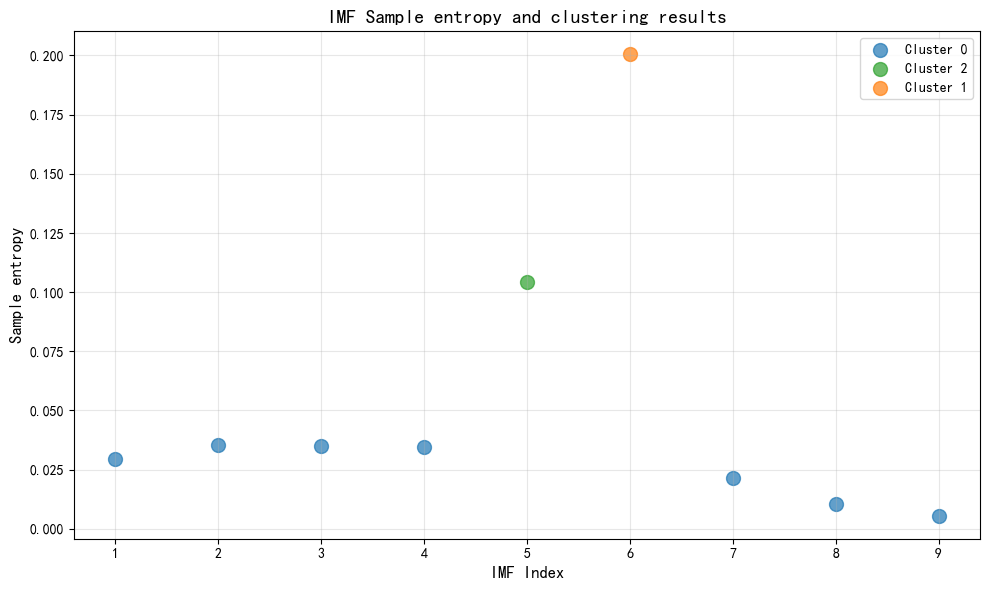


聚类结果:
IMF 1: 样本熵 = 0.0292, 所属聚类 = 0
IMF 2: 样本熵 = 0.0353, 所属聚类 = 0
IMF 3: 样本熵 = 0.0348, 所属聚类 = 0
IMF 4: 样本熵 = 0.0344, 所属聚类 = 0
IMF 5: 样本熵 = 0.1042, 所属聚类 = 2
IMF 6: 样本熵 = 0.2005, 所属聚类 = 1
IMF 7: 样本熵 = 0.0212, 所属聚类 = 0
IMF 8: 样本熵 = 0.0103, 所属聚类 = 0
IMF 9: 样本熵 = 0.0055, 所属聚类 = 0


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --------------------------- 样本熵计算函数 ---------------------------
def calculate_sample_entropy(imfs):
    """计算每个IMF分量的样本熵"""
    sample_entropies = []
    
    for i in range(imfs.shape[1]):
        imf = imfs[:, i]
        # 这里使用简化的样本熵计算方法
        # 实际应用中可以使用更精确的样本熵算法
        entropy = calculate_entropy(imf)
        sample_entropies.append(entropy)
    
    return np.array(sample_entropies)

def calculate_entropy(signal):
    """简化的样本熵计算方法"""
    # 这里使用标准差作为样本熵的近似值
    # 实际应用中可以使用更复杂的样本熵算法
    return np.std(signal)

# --------------------------- 基于样本熵的聚类函数 ---------------------------
def cluster_imfs_by_entropy(imfs, n_clusters=3):
    """基于样本熵对IMF进行聚类"""
    # 计算每个IMF的样本熵
    sample_entropies = calculate_sample_entropy(imfs)
    
    # 将样本熵作为特征进行聚类
    features = sample_entropies.reshape(-1, 1)
    
    # 标准化特征
    feature_scaler = MinMaxScaler()
    normalized_features = feature_scaler.fit_transform(features)
    
    # K-means聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(normalized_features)
    
    return labels, sample_entropies, kmeans

# --------------------------- 绘制样本熵聚类结果图 ---------------------------
def plot_entropy_clustering(imfs, n_clusters=3, save_path='IMF样本熵聚类结果.png'):
    """绘制基于样本熵的IMF聚类结果图并保存到本地"""
    
    # 基于样本熵进行聚类
    labels, sample_entropies, kmeans = cluster_imfs_by_entropy(imfs, n_clusters)
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 设置颜色
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # 为每个IMF绘制点
    for i in range(len(sample_entropies)):
        plt.scatter(i+1, sample_entropies[i], 
                   c=colors[labels[i]], 
                   s=100, 
                   label=f'Cluster {labels[i]}' if i == np.where(labels == labels[i])[0][0] else "",
                   alpha=0.7)
    
    # 设置坐标轴和标题
    plt.xlabel('IMF Index', fontsize=12)
    plt.ylabel('Sample entropy', fontsize=12)
    plt.title('IMF Sample entropy and clustering results', fontsize=14, fontweight='bold')
    
    # 设置x轴刻度
    plt.xticks(range(1, len(sample_entropies)+1))
    
    # 添加网格
    plt.grid(True, alpha=0.3)
    
    # 添加图例
    plt.legend()
    
    # 调整布局
    plt.tight_layout()
    
    # 保存图片到本地
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图片已保存到: {save_path}")
    
    # 显示图形
    plt.show()
    
    return labels, sample_entropies

# --------------------------- 使用示例 ---------------------------
# 假设您已经有了CEEMDAN分解得到的imfs
# 调用函数生成图片并保存
print("开始基于样本熵的IMF聚类...")
labels, entropies = plot_entropy_clustering(imfs, n_clusters=3, save_path='IMF样本熵聚类结果.png')

# 输出聚类结果
print("\n聚类结果:")
for i in range(len(labels)):
    print(f"IMF {i+1}: 样本熵 = {entropies[i]:.4f}, 所属聚类 = {labels[i]}")

开始生成五个单独的IMF图...


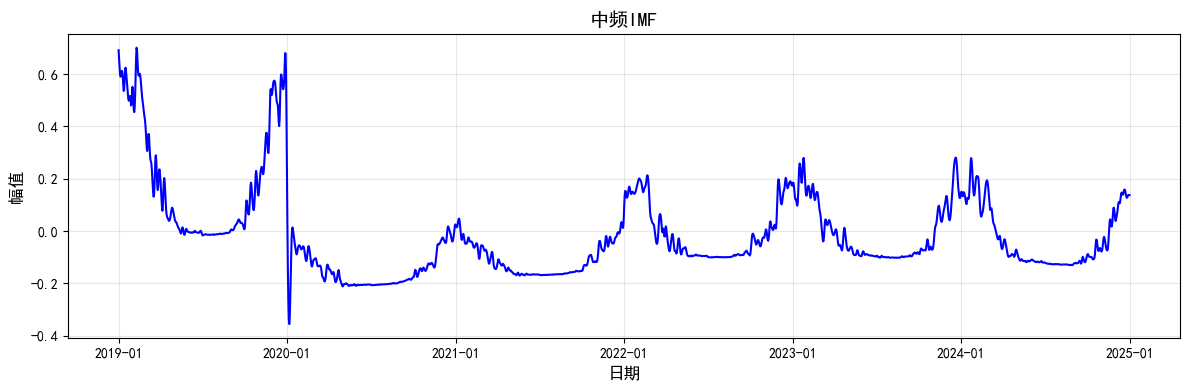

中频IMF 已保存到: ./中频IMF.png


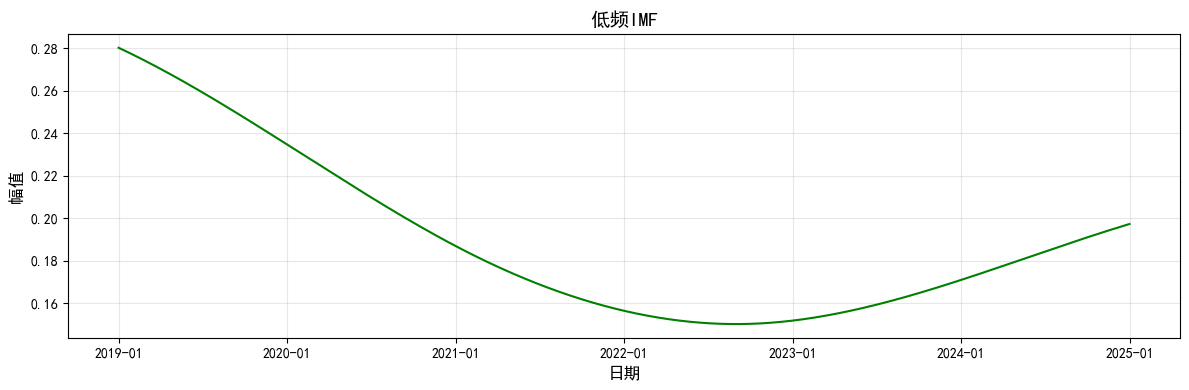

低频IMF 已保存到: ./低频IMF.png


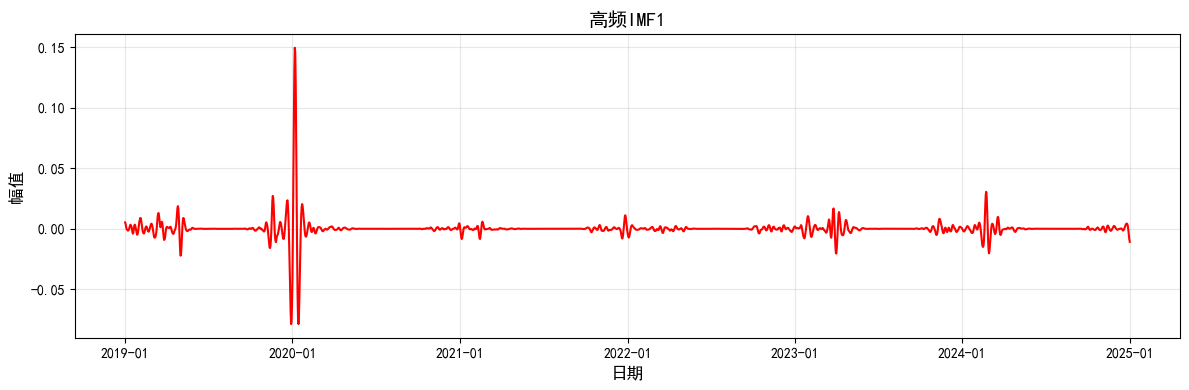

高频IMF1 已保存到: ./高频IMF1.png


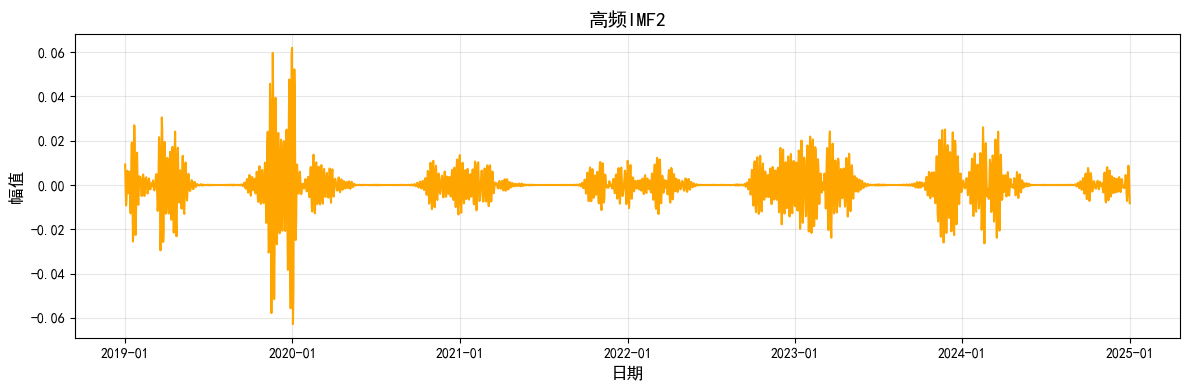

高频IMF2 已保存到: ./高频IMF2.png


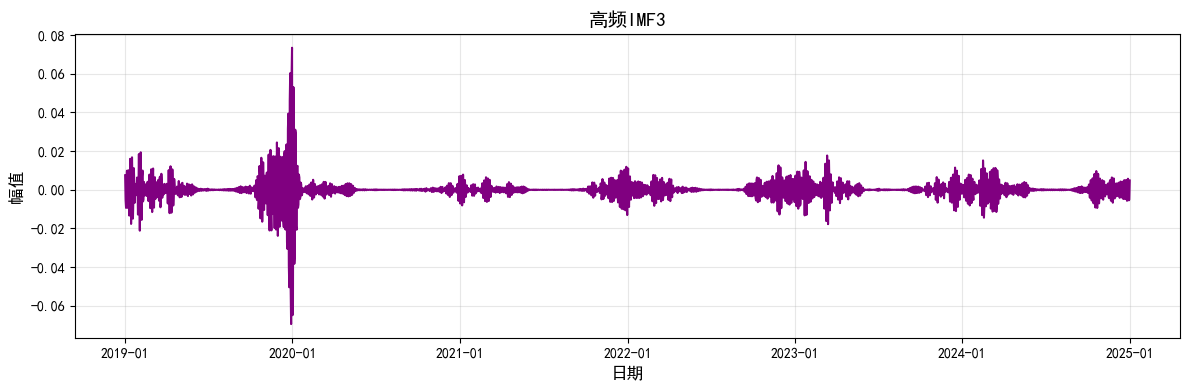

高频IMF3 已保存到: ./高频IMF3.png

所有IMF图已保存:
1. 中频IMF: ./中频IMF.png
2. 低频IMF: ./低频IMF.png
3. 高频IMF1: ./高频IMF1.png
4. 高频IMF2: ./高频IMF2.png
5. 高频IMF3: ./高频IMF3.png


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from vmdpy import VMD
import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --------------------------- VMD分解函数 ---------------------------
def vmd_decomposition(signal, alpha, K):
    """VMD分解"""
    imfs, _, _ = VMD(signal.flatten(), alpha=alpha, K=K, tau=0, DC=0, init=1, tol=1e-6)
    return imfs

# --------------------------- 绘制五个单独的IMF图 ---------------------------
def plot_five_separate_imfs(imfs, labels, merged_components, high_freq_cluster, df, save_dir='./'):
    """将五个IMF分别绘制在五张单独的图片上"""
    
    # 获取日期索引
    dates = df.index[:len(imfs)]
    
    # 计算各聚类的频率特征
    cluster_features = []
    for i in range(np.max(labels)+1):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) > 0:
            # 使用原始IMF计算过零率
            avg_zero_crossing = np.mean([np.sum(np.diff(np.sign(imfs[:, idx])) != 0) / len(imfs) for idx in cluster_indices])
            cluster_features.append(avg_zero_crossing)
        else:
            cluster_features.append(0)
    
    # 排除高频聚类后找到中频和低频
    cluster_features_copy = cluster_features.copy()
    cluster_features_copy[high_freq_cluster] = 0  # 排除高频聚类
    
    # 找到中频聚类（过零率居中）
    sorted_clusters = np.argsort(cluster_features_copy)
    mid_freq_cluster = sorted_clusters[-1]  # 过零率次高的作为中频
    
    # 找到低频聚类（过零率最低）
    low_freq_cluster = sorted_clusters[0]  # 过零率最低的作为低频
    
    # 计算中频IMF
    mid_freq_indices = np.where(labels == mid_freq_cluster)[0]
    mid_freq_imf = np.sum(imfs[:, mid_freq_indices], axis=1)
    
    # 计算低频IMF
    low_freq_indices = np.where(labels == low_freq_cluster)[0]
    low_freq_imf = np.sum(imfs[:, low_freq_indices], axis=1)
    
    # 对高频分量进行VMD分解
    high_freq_component = merged_components[:, high_freq_cluster]
    vmd_imfs = vmd_decomposition(high_freq_component, VMD_ALPHA, VMD_K)
    
    # 准备五个IMF数据
    all_imfs = [mid_freq_imf, low_freq_imf]
    for i in range(min(3, vmd_imfs.shape[0])):
        all_imfs.append(vmd_imfs[i])
    
    imf_names = ['中频IMF', '低频IMF', '高频IMF1', '高频IMF2', '高频IMF3']
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    
    # 分别绘制每个IMF
    saved_files = []
    for i, (imf, name, color) in enumerate(zip(all_imfs, imf_names, colors)):
        # 创建新图形
        plt.figure(figsize=(12, 4))
        
        # 绘制IMF
        plt.plot(dates, imf, color=color, linewidth=1.5)
        
        # 设置标题和标签
        plt.title(f'{name}', fontsize=14, fontweight='bold')
        plt.ylabel('幅值', fontsize=12)
        plt.xlabel('日期', fontsize=12)
        
        # 设置x轴格式
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
        
        # 添加网格
        plt.grid(True, alpha=0.3)
        
        # 调整布局
        plt.tight_layout()
        
        # 保存图片
        filename = f'{save_dir}{name}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        saved_files.append(filename)
        
        # 显示图形
        plt.show()
        
        # 关闭图形以释放内存
        plt.close()
        
        print(f"{name} 已保存到: {filename}")
    
    return saved_files, all_imfs, imf_names

# --------------------------- 使用示例 ---------------------------
# 调用函数生成并保存五个单独的IMF图
print("开始生成五个单独的IMF图...")
saved_files, all_imfs, imf_names = plot_five_separate_imfs(
    imfs, labels, merged_components, high_freq_cluster, df, 
    save_dir='./'
)

# 输出分量信息
print(f"\n所有IMF图已保存:")
for i, filename in enumerate(saved_files):
    print(f"{i+1}. {imf_names[i]}: {filename}")